# **GASTROCARE**

In [1]:
# ============================================================
#  PREPROCESSING PENYAKIT LAMBUNG — Google Colab
#  Alur: Basic Cleaning → Split → EDA (train only)
#        → Imputasi → Feature Engineering → Scaling

#Business Questions
1. Bagaimana distribusi penyakit lambung berdasarkan data pasien pada sistem GastroCare selama periode pengujian dataset?
2. Gejala apa yang paling dominan dan memiliki hubungan tertinggi terhadap hasil prediksi penyakit lambung pada GastroCare selama proses analisis data?
3. Bagaimana performa model machine learning GastroCare dalam mengklasifikasikan penyakit lambung berdasarkan data gejala pasien selama proses evaluasi model?



In [2]:
# Install & Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

!pip install gradio -q

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import gradio as gr

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU tersedia       : {len(tf.config.list_physical_devices('GPU')) > 0}")

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version : 2.20.0
GPU tersedia       : True


#Upload File

In [3]:
from google.colab import files
uploaded = files.upload()  # upload: dataset_lambung_dirty.csv

import io
filename = list(uploaded.keys())[0]
df_raw   = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✓ Dataset berhasil dimuat")
print(f"  Shape  : {df_raw.shape}")
print(f"  Kolom  : {df_raw.columns.tolist()}")
print(f"\nDistribusi label:")
print(df_raw['label'].value_counts().to_string())

Saving dataset_lambung_dirty.csv to dataset_lambung_dirty.csv
✓ Dataset berhasil dimuat
  Shape  : (3374, 21)
  Kolom  : ['label', 'nyeri_ulu_hati', 'mual', 'muntah', 'kembung', 'heartburn', 'asam_naik_tenggorokan', 'diare', 'demam', 'penurunan_berat_badan', 'cepat_kenyang', 'muntah_tak_tercerna', 'nyeri_perut_kosong', 'feses_hitam', 'riwayat_nsaid', 'stres_tinggi', 'batuk_kronis', 'suara_serak', 'anemia_lemas', 'nafsu_makan_hilang', 'nyeri_dada']

Distribusi label:
label
Gastroparesis           427
Gastritis               424
GERD                    424
Sehat                   423
Dispepsia_Fungsional    421
Tukak_Lambung           419
Gastroenteritis         418
Kanker_Lambung          418


#Konstanta

In [4]:
FITUR_ORDINAL = ['nyeri_ulu_hati']
FITUR_BINER   = [
    'mual', 'muntah', 'kembung', 'heartburn', 'asam_naik_tenggorokan',
    'diare', 'demam', 'penurunan_berat_badan', 'cepat_kenyang',
    'muntah_tak_tercerna', 'nyeri_perut_kosong', 'feses_hitam',
    'riwayat_nsaid', 'stres_tinggi', 'batuk_kronis', 'suara_serak',
    'anemia_lemas', 'nafsu_makan_hilang', 'nyeri_dada'
]
FITUR_SEMUA = FITUR_ORDINAL + FITUR_BINER
LABEL       = 'label'
CLASSES     = [
    'Sehat', 'Gastritis', 'Tukak_Lambung', 'GERD',
    'Dispepsia_Fungsional', 'Gastroparesis', 'Gastroenteritis', 'Kanker_Lambung'
]

#Basic Data Cleaning

In [5]:
print("\n" + "="*60)
print("STEP 1 — BASIC DATA CLEANING")
print("="*60)

df = df_raw.copy()
print(f"\nShape awal : {df.shape}")

# 1a. Drop baris duplikat
n_awal = len(df)
df     = df.drop_duplicates()
print(f"[1a] Drop duplikat         : -{n_awal - len(df)} baris → sisa {len(df)}")

# 1b. Outlier fitur ordinal → set NaN
#     nyeri_ulu_hati hanya valid di {0, 1, 2, 3}
mask_ord  = ~df['nyeri_ulu_hati'].isin([0, 1, 2, 3]) & df['nyeri_ulu_hati'].notna()
n_out_ord = mask_ord.sum()
df.loc[mask_ord, 'nyeri_ulu_hati'] = np.nan
print(f"[1b] Outlier ordinal → NaN : {n_out_ord} nilai")

# 1c. Outlier fitur biner → set NaN
#     Semua fitur biner hanya valid di {0, 1}
n_out_bin = 0
for col in FITUR_BINER:
    mask_bin   = ~df[col].isin([0, 1]) & df[col].notna()
    n_out_bin += mask_bin.sum()
    df.loc[mask_bin, col] = np.nan
print(f"[1c] Outlier biner → NaN   : {n_out_bin} nilai")

print(f"\nShape setelah cleaning : {df.shape}")
print(f"Total null             : {df.isnull().sum().sum()}")


STEP 1 — BASIC DATA CLEANING

Shape awal : (3374, 21)
[1a] Drop duplikat         : -99 baris → sisa 3275
[1b] Outlier ordinal → NaN : 84 nilai
[1c] Outlier biner → NaN   : 556 nilai

Shape setelah cleaning : (3275, 21)
Total null             : 4611


#Split Dataset

In [6]:
print("\n" + "="*60)
print("STEP 2 — SPLIT DATASET (70% / 15% / 15%)")
print("="*60)

X = df[FITUR_SEMUA]
y = df[LABEL]

# Split 1: pisah train (70%) vs sementara (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split 2: sementara (30%) → val (15%) + test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain : {len(X_train):>5} baris ({len(X_train)/len(df)*100:.1f}%)")
print(f"Val   : {len(X_val):>5} baris ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test  : {len(X_test):>5} baris ({len(X_test)/len(df)*100:.1f}%)")

print(f"\nDistribusi kelas TRAIN:")
print(y_train.value_counts().to_string())


STEP 2 — SPLIT DATASET (70% / 15% / 15%)

Train :  2292 baris (70.0%)
Val   :   491 baris (15.0%)
Test  :   492 baris (15.0%)

Distribusi kelas TRAIN:
label
Gastritis               293
Tukak_Lambung           293
Sehat                   291
GERD                    288
Dispepsia_Fungsional    288
Kanker_Lambung          286
Gastroparesis           281
Gastroenteritis         272


# Data Dictionary

Dataset **GastroCare** merupakan dataset klasifikasi penyakit lambung berbasis gejala klinis pasien. Dataset ini digunakan untuk membangun model machine learning dalam memprediksi jenis penyakit gastrointestinal berdasarkan kombinasi gejala, faktor risiko, dan tanda klinis pasien. Dataset disusun berdasarkan referensi medis mengenai:
- Gastritis
- GERD
- Tukak Lambung
- Dispepsia Fungsional
- Gastroenteritis
- Gastroparesis
- Kanker Lambung

Setiap baris pada dataset merepresentasikan satu pasien, sedangkan setiap kolom merepresentasikan gejala atau faktor klinis tertentu.

**Struktur Dataset**

| Kolom | Deskripsi Medis | Tipe Data |
|---|---|---|
| nyeri_ulu_hati | Nyeri atau rasa perih pada area epigastrium/ulu hati | Ordinal |
| mual | Sensasi ingin muntah | Biner |
| muntah | Pengeluaran isi lambung melalui mulut | Biner |
| kembung | Perasaan penuh atau begah pada perut | Biner |
| heartburn | Sensasi terbakar pada dada atau ulu hati akibat refluks asam lambung | Biner |
| asam_naik_tenggorokan | Kondisi refluks asam lambung menuju kerongkongan | Biner |
| diare | BAB cair lebih dari 3 kali sehari | Biner |
| demam | Peningkatan suhu tubuh akibat inflamasi atau infeksi | Biner |
| penurunan_berat_badan | Penurunan berat badan tanpa penyebab jelas | Biner |
| cepat_kenyang | Cepat merasa kenyang meskipun makan sedikit | Biner |
| muntah_tak_tercerna | Muntah berisi makanan yang belum tercerna sempurna | Biner |
| nyeri_perut_kosong | Nyeri lambung saat perut kosong | Biner |
| feses_hitam | BAB berwarna hitam akibat perdarahan saluran cerna atas | Biner |
| riwayat_nsaid | Riwayat penggunaan obat NSAID seperti aspirin atau ibuprofen | Biner |
| stres_tinggi | Tingkat stres psikologis tinggi | Biner |
| batuk_kronis | Batuk berkepanjangan akibat iritasi refluks asam | Biner |
| suara_serak | Perubahan suara akibat iritasi laring oleh refluks asam | Biner |
| anemia_lemas | Kondisi lemah akibat anemia atau perdarahan kronis | Biner |
| nafsu_makan_hilang | Penurunan atau hilangnya keinginan makan | Biner |
| nyeri_dada | Nyeri atau rasa terbakar pada dada | Biner |
| label | Jenis penyakit gastrointestinal pasien | Categorical |

## Keterangan Nilai Fitur

Dataset GastroCare menggunakan dua jenis representasi data, yaitu **ordinal** dan **biner**.

### 1. Fitur Ordinal

Fitur ordinal digunakan untuk menggambarkan **tingkat keparahan gejala** yang dialami pasien. Semakin tinggi nilai yang diberikan, semakin berat intensitas gejala yang dirasakan.

| Nilai | Keterangan |
|--------|------------|
| 0 | Tidak ada gejala |
| 1 | Gejala ringan |
| 2 | Gejala sedang |
| 3 | Gejala berat |

**Fitur ordinal:**
- `nyeri_ulu_hati`

### 2. Fitur Biner

Fitur biner digunakan untuk menunjukkan **ada atau tidaknya gejala maupun faktor risiko** pada pasien.

| Nilai | Keterangan |
|--------|------------|
| 0 | Tidak (gejala/faktor risiko tidak ditemukan) |
| 1 | Ya (gejala/faktor risiko ditemukan) |

**Fitur biner:**
- `mual`
- `muntah`
- `kembung`
- `heartburn`
- `asam_naik_tenggorokan`
- `diare`
- `demam`
- `penurunan_berat_badan`
- `cepat_kenyang`
- `muntah_tak_tercerna`
- `nyeri_perut_kosong`
- `feses_hitam`
- `riwayat_nsaid`
- `stres_tinggi`
- `batuk_kronis`
- `suara_serak`
- `anemia_lemas`
- `nafsu_makan_hilang`
- `nyeri_dada`

**Target Klasifikasi**
Kolom `label` merupakan target klasifikasi yang berisi kategori penyakit lambung berikut:
| Label | Deskripsi |
|---|---|
| Gastritis | Peradangan pada mukosa lambung |
| GERD | Refluks asam lambung ke esofagus |
| Tukak_Lambung | Luka pada lapisan lambung atau duodenum |
| Dispepsia_Fungsional | Gangguan pencernaan tanpa kelainan organik jelas |
| Gastroenteritis | Infeksi atau peradangan lambung dan usus |
| Gastroparesis | Gangguan pengosongan lambung |
| Kanker_Lambung | Keganasan pada jaringan lambung |
| Sehat | Tidak menunjukkan gejala dominan penyakit lambung |

Pada proses machine learning, seluruh fitur gejala digunakan sebagai variabel independen (X), sedangkan kolom label digunakan sebagai target klasifikasi (y) untuk memprediksi jenis penyakit lambung pasien.

#EDA


STEP 3 — EDA (train set only)

Null per kolom (train):
                       jumlah  persen%
feses_hitam               272    11.87
riwayat_nsaid             245    10.69
nyeri_ulu_hati            242    10.56
anemia_lemas              224     9.77
nyeri_perut_kosong        186     8.12
muntah_tak_tercerna       169     7.37
stres_tinggi              166     7.24
asam_naik_tenggorokan     162     7.07
heartburn                 161     7.02
cepat_kenyang             146     6.37
nafsu_makan_hilang        142     6.20
suara_serak               140     6.11
batuk_kronis              140     6.11
mual                      138     6.02
kembung                   136     5.93
muntah                    125     5.45
penurunan_berat_badan     125     5.45
diare                     118     5.15
demam                     103     4.49
nyeri_dada                 86     3.75

Rata-rata gejala per kelas (train, tanpa null):
                      nyeri_ulu_hati   mual  muntah  kembung  heartburn  asa

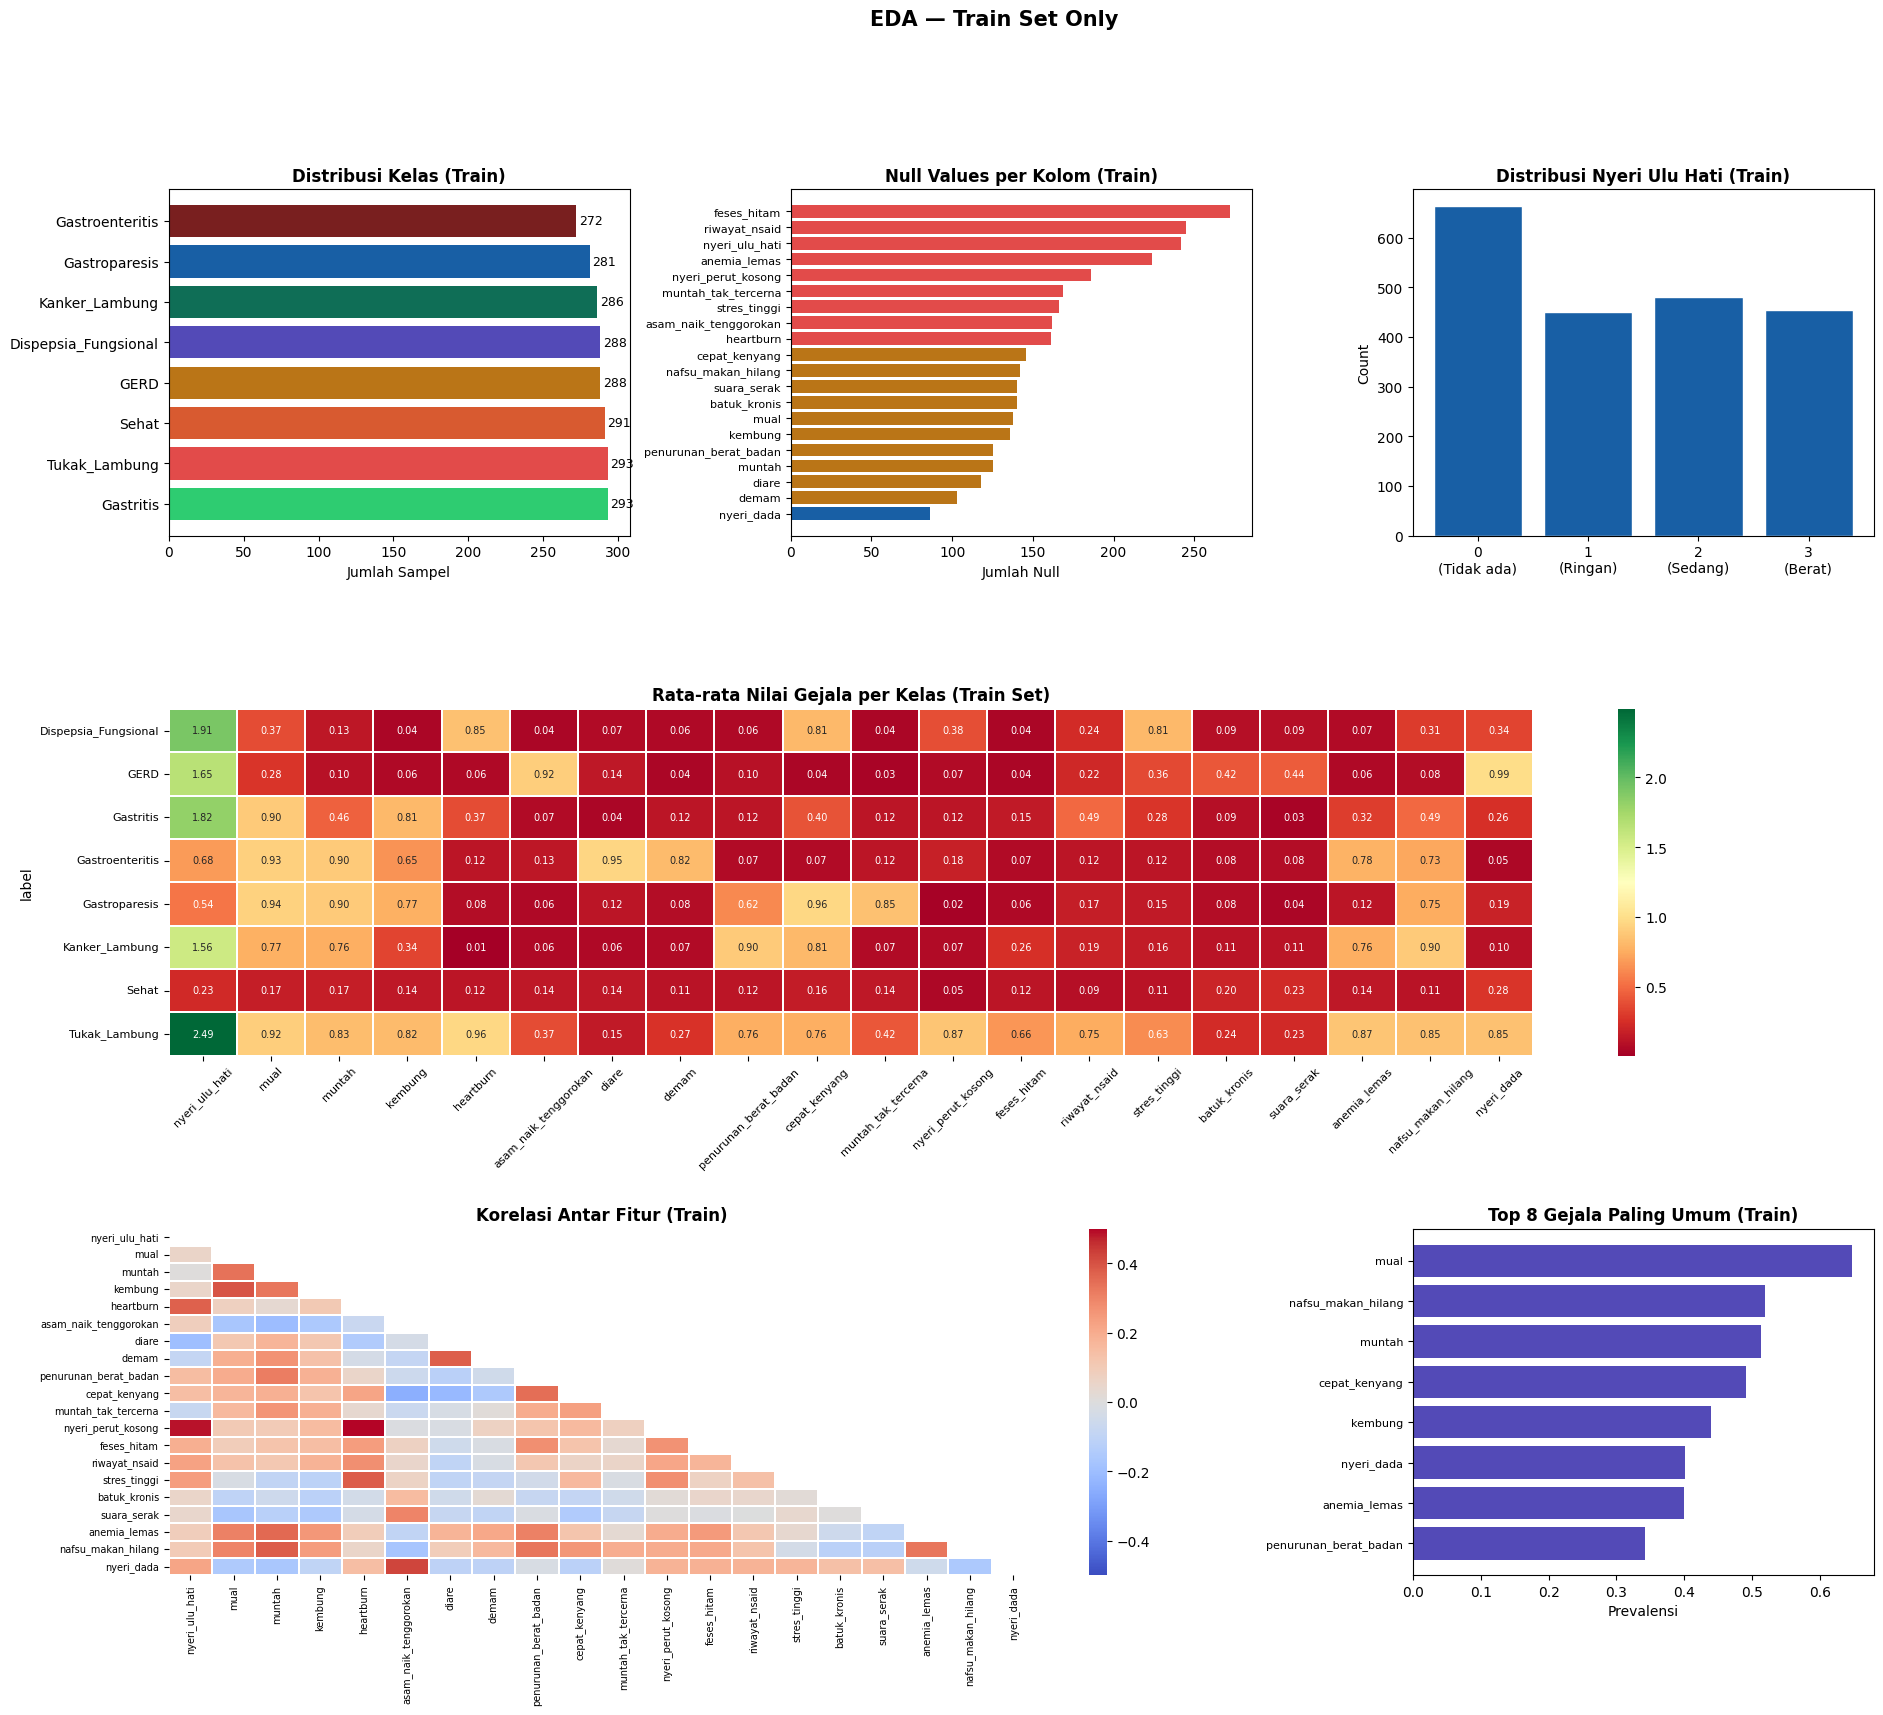


[VIZ] EDA chart tersimpan → eda_train_only.png


In [7]:
print("\n" + "="*60)
print("STEP 3 — EDA (train set only)")
print("="*60)

# Gabungkan X_train + y_train untuk EDA
df_train = X_train.copy()
df_train[LABEL] = y_train.values

# -- Info null pada train --
print("\nNull per kolom (train):")
null_info = pd.DataFrame({
    'jumlah' : df_train[FITUR_SEMUA].isnull().sum(),
    'persen%': (df_train[FITUR_SEMUA].isnull().sum() / len(df_train) * 100).round(2)
})
print(null_info[null_info['jumlah'] > 0].sort_values('jumlah', ascending=False).to_string())

# -- Rata-rata gejala per kelas (dari baris yang tidak null) --
df_train_valid = df_train.dropna(subset=FITUR_SEMUA)
print(f"\nRata-rata gejala per kelas (train, tanpa null):")
print(df_train_valid.groupby(LABEL)[FITUR_SEMUA].mean().round(3).to_string())

# -- Visualisasi --
PAL = ['#2ecc71','#E24B4A','#D85A30','#BA7517','#534AB7','#0F6E56','#185FA5','#791F1F']

fig = plt.figure(figsize=(22, 18))
fig.suptitle('EDA — Train Set Only', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

# Plot 1: Distribusi kelas
ax1 = fig.add_subplot(gs[0, 0])
vc  = y_train.value_counts()
bars = ax1.barh(vc.index, vc.values, color=PAL[:len(vc)])
ax1.set_title('Distribusi Kelas (Train)', fontweight='bold')
ax1.set_xlabel('Jumlah Sampel')
for bar, v in zip(bars, vc.values):
    ax1.text(v + 2, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=9)

# Plot 2: Null per kolom
ax2 = fig.add_subplot(gs[0, 1])
null_sorted = null_info[null_info['jumlah'] > 0].sort_values('jumlah')
c_null = ['#E24B4A' if p > 7 else '#BA7517' if p > 4 else '#185FA5'
          for p in null_sorted['persen%']]
ax2.barh(null_sorted.index, null_sorted['jumlah'], color=c_null)
ax2.set_title('Null Values per Kolom (Train)', fontweight='bold')
ax2.set_xlabel('Jumlah Null')
ax2.tick_params(axis='y', labelsize=8)

# Plot 3: Distribusi nyeri_ulu_hati
ax3 = fig.add_subplot(gs[0, 2])
nuh = df_train['nyeri_ulu_hati'].dropna()
ax3.hist(nuh, bins=[-0.5, 0.5, 1.5, 2.5, 3.5], color='#185FA5',
         edgecolor='white', rwidth=0.8)
ax3.set_xticks([0, 1, 2, 3])
ax3.set_xticklabels(['0\n(Tidak ada)', '1\n(Ringan)', '2\n(Sedang)', '3\n(Berat)'])
ax3.set_title('Distribusi Nyeri Ulu Hati (Train)', fontweight='bold')
ax3.set_ylabel('Count')

# Plot 4: Heatmap rata-rata gejala per kelas
ax4 = fig.add_subplot(gs[1, :])
pivot = df_train_valid.groupby(LABEL)[FITUR_SEMUA].mean().round(2)
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax4,
            linewidths=0.3, annot_kws={'size': 7})
ax4.set_title('Rata-rata Nilai Gejala per Kelas (Train Set)', fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=8)
ax4.tick_params(axis='y', rotation=0, labelsize=8)

# Plot 5: Heatmap korelasi antar fitur
ax5 = fig.add_subplot(gs[2, :2])
corr = df_train_valid[FITUR_SEMUA].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, ax=ax5,
            linewidths=0.3, vmin=-0.5, vmax=0.5)
ax5.set_title('Korelasi Antar Fitur (Train)', fontweight='bold')
ax5.tick_params(axis='both', labelsize=7)

# Plot 6: Top 8 gejala paling umum
ax6 = fig.add_subplot(gs[2, 2])
prev = df_train_valid[FITUR_BINER].mean().sort_values(ascending=False).head(8)
ax6.barh(prev.index[::-1], prev.values[::-1], color='#534AB7')
ax6.set_title('Top 8 Gejala Paling Umum (Train)', fontweight='bold')
ax6.set_xlabel('Prevalensi')
ax6.tick_params(axis='y', labelsize=8)

plt.savefig('eda_train_only.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\n[VIZ] EDA chart tersimpan → eda_train_only.png")

#Advance Preprocessing & Feature Engineering

In [8]:
print("\n" + "="*60)
print("STEP 4 — PREPROCESSING & FEATURE ENGINEERING")
print("         Fit: TRAIN | Transform: TRAIN + VAL + TEST")
print("="*60)

# -- 4a. Imputasi missing values dengan modus per kelas ------
# Modus HANYA dihitung dari train set
print("\n[4a] Hitung modus per kelas dari TRAIN...")

df_tr_ref = X_train.copy()
df_tr_ref[LABEL] = y_train.values

impute_map = {}  # {kolom: {kelas: nilai_modus}}
for col in FITUR_SEMUA:
    impute_map[col] = {}
    for kelas in CLASSES:
        subset = df_tr_ref[df_tr_ref[LABEL] == kelas][col].dropna()
        modus  = subset.mode()
        impute_map[col][kelas] = int(modus[0]) if len(modus) > 0 else 0

print("  Contoh impute_map['nyeri_ulu_hati']:", impute_map['nyeri_ulu_hati'])

def imputasi(X_df, y_series):
    """
    Isi nilai null menggunakan modus per kelas.
    impute_map sudah di-fit dari train set.
    """
    Xc = X_df.copy()
    for col in FITUR_SEMUA:
        null_idx = Xc[Xc[col].isna()].index
        for idx in null_idx:
            kelas = y_series.loc[idx]
            kelas = kelas if kelas in impute_map[col] else CLASSES[0]
            Xc.loc[idx, col] = impute_map[col][kelas]
    # Pastikan semua kolom bertipe integer
    for col in FITUR_SEMUA:
        Xc[col] = Xc[col].astype(int)
    return Xc

X_train_imp = imputasi(X_train, y_train)
X_val_imp   = imputasi(X_val,   y_val)
X_test_imp  = imputasi(X_test,  y_test)

print(f"\n  Null train setelah imputasi : {X_train_imp.isnull().sum().sum()}")
print(f"  Null val   setelah imputasi : {X_val_imp.isnull().sum().sum()}")
print(f"  Null test  setelah imputasi : {X_test_imp.isnull().sum().sum()}")

# -- 4b. Feature Engineering ---------------------------------
# Interaction features: kombinasi gejala yang secara klinis
# sering muncul bersamaan — dibuat dari data yang sudah diimputasi
print("\n[4b] Feature Engineering — interaction features...")

def feature_engineering(X_df):
    Xe = X_df.copy()

    # =========================
    # FEATURE LAMA
    # =========================
    Xe['gejala_refluks'] = ((Xe['heartburn'] >= 1) & (Xe['asam_naik_tenggorokan'] >= 1)).astype(int)
    Xe['gejala_ulkus'] = ((Xe['nyeri_perut_kosong'] >= 1) & (Xe['feses_hitam'] >= 1)).astype(int)
    Xe['gejala_infeksi'] = ((Xe['diare'] >= 1) & (Xe['demam'] >= 1)).astype(int)
    Xe['gejala_kanker'] = ((Xe['penurunan_berat_badan'] >= 1) &
                           (Xe['anemia_lemas'] >= 1) &
                           (Xe['nafsu_makan_hilang'] >= 1)).astype(int)
    Xe['gejala_motilitas'] = ((Xe['muntah_tak_tercerna'] >= 1) &
                              (Xe['cepat_kenyang'] >= 1)).astype(int)
    Xe['gejala_fungsional'] = ((Xe['kembung'] >= 1) &
                               (Xe['stres_tinggi'] >= 1)).astype(int)

    Xe['total_gejala'] = Xe[FITUR_SEMUA].sum(axis=1)

    # =========================
    # ✅ TAMBAHAN FITUR BARU (INI YANG BENAR)
    # =========================
    Xe['skor_gerd'] = (
        Xe['heartburn']*2 +
        Xe['asam_naik_tenggorokan']*2 +
        Xe['nyeri_dada']
    )

    Xe['skor_gastritis'] = (
        Xe['nyeri_ulu_hati'] +
        Xe['mual'] +
        Xe['kembung']
    )

    Xe['skor_kanker'] = (
        Xe['penurunan_berat_badan']*2 +
        Xe['anemia_lemas']*2 +
        Xe['nafsu_makan_hilang']*2
    )

    Xe['skor_infeksi'] = (
        Xe['diare'] +
        Xe['demam']
    )

    return Xe

X_train_fe = feature_engineering(X_train_imp)
X_val_fe   = feature_engineering(X_val_imp)
X_test_fe  = feature_engineering(X_test_imp)

FITUR_FINAL = list(X_train_fe.columns)
print(f"  Fitur asli         : {len(FITUR_SEMUA)}")
print(f"  Fitur baru (FE)    : {len(FITUR_FINAL) - len(FITUR_SEMUA)}")
print(f"  Total fitur final  : {len(FITUR_FINAL)}")
print(f"  Nama fitur baru    : {FITUR_FINAL[len(FITUR_SEMUA):]}")

# -- 4c. Label Encoding --------------------------------------
print("\n[4c] Label Encoding...")

le = LabelEncoder()
le.fit(CLASSES)                          # fit dari konstanta CLASSES
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(f"  Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# -- 4d. StandardScaler — fit HANYA dari train ---------------
print("\n[4d] StandardScaler — fit TRAIN, transform semua...")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fe)  # fit + transform
X_val_scaled   = scaler.transform(X_val_fe)         # transform saja
X_test_scaled  = scaler.transform(X_test_fe)         # transform saja

print(f"  Mean scaler (5 fitur pertama): {scaler.mean_[:5].round(4)}")
print(f"  Std  scaler (5 fitur pertama): {scaler.scale_[:5].round(4)}")
print(f"\n  X_train_scaled shape : {X_train_scaled.shape}")
print(f"  X_val_scaled   shape : {X_val_scaled.shape}")
print(f"  X_test_scaled  shape : {X_test_scaled.shape}")


STEP 4 — PREPROCESSING & FEATURE ENGINEERING
         Fit: TRAIN | Transform: TRAIN + VAL + TEST

[4a] Hitung modus per kelas dari TRAIN...
  Contoh impute_map['nyeri_ulu_hati']: {'Sehat': 0, 'Gastritis': 1, 'Tukak_Lambung': 3, 'GERD': 3, 'Dispepsia_Fungsional': 2, 'Gastroparesis': 0, 'Gastroenteritis': 0, 'Kanker_Lambung': 3}

  Null train setelah imputasi : 0
  Null val   setelah imputasi : 0
  Null test  setelah imputasi : 0

[4b] Feature Engineering — interaction features...
  Fitur asli         : 20
  Fitur baru (FE)    : 11
  Total fitur final  : 31
  Nama fitur baru    : ['gejala_refluks', 'gejala_ulkus', 'gejala_infeksi', 'gejala_kanker', 'gejala_motilitas', 'gejala_fungsional', 'total_gejala', 'skor_gerd', 'skor_gastritis', 'skor_kanker', 'skor_infeksi']

[4c] Label Encoding...
  Mapping: {np.str_('Dispepsia_Fungsional'): np.int64(0), np.str_('GERD'): np.int64(1), np.str_('Gastritis'): np.int64(2), np.str_('Gastroenteritis'): np.int64(3), np.str_('Gastroparesis'): np.int64(4)

#Simpan semua artefak & Split

In [9]:
print("\n" + "="*60)
print("SIMPAN ARTEFAK")
print("="*60)

# Split CSV (untuk audit / debug)
df_train_out = X_train_fe.copy(); df_train_out[LABEL] = y_train.values
df_val_out   = X_val_fe.copy();   df_val_out[LABEL]   = y_val.values
df_test_out  = X_test_fe.copy();  df_test_out[LABEL]  = y_test.values

df_train_out.to_csv('split_train.csv', index=False)
df_val_out.to_csv(  'split_val.csv',   index=False)
df_test_out.to_csv( 'split_test.csv',  index=False)

# Array numpy siap pakai untuk training model
np.save('X_train.npy', X_train_scaled)
np.save('X_val.npy',   X_val_scaled)
np.save('X_test.npy',  X_test_scaled)
np.save('y_train.npy', y_train_enc)
np.save('y_val.npy',   y_val_enc)
np.save('y_test.npy',  y_test_enc)

# Artefak preprocessing (untuk dipakai saat inference/Gradio)
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(le,          'label_encoder.pkl')
joblib.dump(impute_map,  'impute_map.pkl')
joblib.dump(FITUR_FINAL, 'features_list.pkl')

print("\nFile yang dihasilkan:")
print("  split_train.csv   → data train + label (untuk referensi)")
print("  split_val.csv     → data val   + label (untuk referensi)")
print("  split_test.csv    → data test  + label (untuk referensi)")
print("  X_train.npy       → fitur train scaled, siap training")
print("  X_val.npy         → fitur val   scaled, siap validasi")
print("  X_test.npy        → fitur test  scaled, siap evaluasi")
print("  y_train/val/test  → label encoded")
print("  scaler.pkl        → StandardScaler (fit dari train)")
print("  label_encoder.pkl → LabelEncoder (8 kelas)")
print("  impute_map.pkl    → modus per kelas (fit dari train)")
print("  features_list.pkl → urutan 27 fitur final")

# Download semua file ke komputer
files.download('split_train.csv')
files.download('split_val.csv')
files.download('split_test.csv')
files.download('X_train.npy')
files.download('X_val.npy')
files.download('X_test.npy')
files.download('y_train.npy')
files.download('y_val.npy')
files.download('y_test.npy')
files.download('scaler.pkl')
files.download('label_encoder.pkl')
files.download('impute_map.pkl')
files.download('features_list.pkl')
files.download('eda_train_only.png')

print("\n✓ Semua file berhasil didownload!")
print("  Langkah berikutnya: load X_train.npy → bangun model → training!")


SIMPAN ARTEFAK

File yang dihasilkan:
  split_train.csv   → data train + label (untuk referensi)
  split_val.csv     → data val   + label (untuk referensi)
  split_test.csv    → data test  + label (untuk referensi)
  X_train.npy       → fitur train scaled, siap training
  X_val.npy         → fitur val   scaled, siap validasi
  X_test.npy        → fitur test  scaled, siap evaluasi
  y_train/val/test  → label encoded
  scaler.pkl        → StandardScaler (fit dari train)
  label_encoder.pkl → LabelEncoder (8 kelas)
  impute_map.pkl    → modus per kelas (fit dari train)
  features_list.pkl → urutan 27 fitur final


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Semua file berhasil didownload!
  Langkah berikutnya: load X_train.npy → bangun model → training!


#Klasifikasi Penyakit Lambung - Deep Learning dengan TensorFlow

## Processing File

In [10]:
# [1] Processing File

X_train = np.load('X_train.npy')
X_val   = np.load('X_val.npy')
X_test  = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')
y_test  = np.load('y_test.npy')

scaler      = joblib.load('scaler.pkl')
le          = joblib.load('label_encoder.pkl')
impute_map  = joblib.load('impute_map.pkl')
FITUR_FINAL = joblib.load('features_list.pkl')

N_FEATURES = X_train.shape[1]
N_CLASSES  = len(le.classes_)
CLASSES    = list(le.classes_)

print(f"\n✓ Data berhasil dimuat")
print(f"  X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"  Fitur   : {N_FEATURES}     |  Kelas   : {N_CLASSES}")
print(f"  Kelas   : {CLASSES}")


✓ Data berhasil dimuat
  X_train : (2292, 31)  |  y_train : (2292,)
  X_val   : (491, 31)    |  y_val   : (491,)
  X_test  : (492, 31)   |  y_test  : (492,)
  Fitur   : 31     |  Kelas   : 8
  Kelas   : [np.str_('Dispepsia_Fungsional'), np.str_('GERD'), np.str_('Gastritis'), np.str_('Gastroenteritis'), np.str_('Gastroparesis'), np.str_('Kanker_Lambung'), np.str_('Sehat'), np.str_('Tukak_Lambung')]


## Custom Components

In [11]:
# [2a] Custom Layer — ResidualBlock─────────────────────────
# Mengimplementasikan skip connection (seperti ResNet) pada MLP
# Input → Dense → BN → ReLU → Dense → BN → (+skip) → ReLU
# Jika dimensi berbeda, pakai projection layer untuk menyamakan

class ResidualBlock(layers.Layer):
    """
    Custom Layer: Residual (Skip Connection) Block untuk MLP.
    Membantu gradient flow dan mencegah vanishing gradient
    pada jaringan yang dalam.
    """
    def __init__(self, units, dropout_rate=0.3, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        self.units        = units
        self.dropout_rate = dropout_rate

        self.dense1    = layers.Dense(units, use_bias=False)
        self.bn1       = layers.BatchNormalization()
        self.act1      = layers.Activation('relu')
        self.dropout1  = layers.Dropout(dropout_rate)

        self.dense2    = layers.Dense(units, use_bias=False)
        self.bn2       = layers.BatchNormalization()

        # Projection: menyamakan dimensi input & output untuk skip connection
        self.projection = layers.Dense(units, use_bias=False)
        self.bn_proj    = layers.BatchNormalization()

        self.act_out = layers.Activation('relu')

    def call(self, inputs, training=False):
        # Main path
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        x = self.act1(x)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.bn2(x, training=training)

        # Skip connection (selalu pakai projection untuk fleksibilitas)
        skip = self.projection(inputs)
        skip = self.bn_proj(skip, training=training)

        # Add & activate
        out = self.act_out(x + skip)
        return out

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'dropout_rate': self.dropout_rate})
        return config

In [12]:
# [2b] Custom Loss — Focal Loss────────────────────────────
# Focal Loss: modifikasi cross-entropy yang fokus pada sampel
# yang sulit diklasifikasikan (hard examples).
#  untuk dataset yang sedikit imbalanced.
# FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
#   gamma > 0 → down-weight easy examples
#   alpha      → balancing factor

class FocalLoss(keras.losses.Loss):
    """
    Custom Loss: Categorical Focal Loss.
    gamma : focusing parameter (biasanya 2.0)
    alpha : class balancing factor (0.25 default)
    """
    def __init__(self, gamma=3.0, alpha=0.25, name='focal_loss', **kwargs):
        super(FocalLoss, self).__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # Konversi label ke one-hot jika belum
        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=N_CLASSES)
        y_true_oh = tf.cast(y_true_oh, tf.float32)

        # Clip prediction supaya tidak log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross entropy per kelas
        ce = -y_true_oh * tf.math.log(y_pred)

        # Focal weight: (1 - p_t)^gamma
        p_t   = tf.reduce_sum(y_true_oh * y_pred, axis=-1, keepdims=True)
        focal = tf.pow(1.0 - p_t, self.gamma)

        # Alpha weighting
        loss = self.alpha * focal * ce
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config

In [13]:
# [2c] Custom Callback — TrainingLogger────────────────────
# Mencatat learning rate, val_accuracy, val_loss setiap epoch
# Menampilkan progress bar dan ringkasan per epoch

class TrainingLogger(keras.callbacks.Callback):
    """
    Custom Callback: Logger pelatihan yang mencatat LR,
    loss, dan accuracy tiap epoch, serta menampilkan
    ringkasan berwarna di akhir training.
    """
    def __init__(self, patience_warn=5):
        super().__init__()
        self.patience_warn = patience_warn
        self.history_log   = []
        self.best_val_acc  = 0.0
        self.no_improve    = 0

    def on_train_begin(self, logs=None):
        print(f"\n{'─'*65}")
        print(f"{'Epoch':>6} {'LR':>10} {'Loss':>10} {'Acc':>8} {'Val Loss':>10} {'Val Acc':>9} {'Status':>8}")
        print(f"{'─'*65}")

    def on_epoch_end(self, epoch, logs=None):
        lr      = float(self.model.optimizer.learning_rate)
        loss    = logs.get('loss', 0)
        acc     = logs.get('accuracy', 0)
        val_loss= logs.get('val_loss', 0)
        val_acc = logs.get('val_accuracy', 0)

        self.history_log.append({
            'epoch': epoch + 1, 'lr': lr,
            'loss': loss, 'accuracy': acc,
            'val_loss': val_loss, 'val_accuracy': val_acc
        })

        # Tandai improvement
        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.no_improve   = 0
            status = '✓ best'
        else:
            self.no_improve += 1
            status = f'  -{self.no_improve}'

        print(f"{epoch+1:>6} {lr:>10.6f} {loss:>10.4f} {acc:>8.4f} "
              f"{val_loss:>10.4f} {val_acc:>9.4f} {status:>8}")

    def on_train_end(self, logs=None):
        best = max(self.history_log, key=lambda x: x['val_accuracy'])
        print(f"{'─'*65}")
        print(f"\n✓ Training selesai!")
        print(f"  Best val_accuracy : {best['val_accuracy']:.4f} (epoch {best['epoch']})")
        print(f"  Best val_loss     : {best['val_loss']:.4f}")
        print(f"  Total epochs      : {len(self.history_log)}")

## Bangun Model - TensorFlow Functional API

In [14]:
print("\n" + "="*60)
print("[3] MEMBANGUN MODEL — Functional API")
print("="*60)

def build_model(n_features, n_classes, learning_rate=0.001):
    # Input─────────
    inputs = keras.Input(shape=(n_features,), name='input_gejala')

    # Blok awal: projection ke dimensi lebih besar─────────
    x = layers.Dense(128, use_bias=False, name='dense_masuk')(inputs)
    x = layers.BatchNormalization(name='bn_masuk')(x)
    x = layers.Activation('relu', name='relu_masuk')(x)
    x = layers.Dropout(0.40, name='drop_masuk')(x)

    # Residual Blocks (Custom Layer)───────────────────────
    x = ResidualBlock(128, dropout_rate=0.35, name='residual_block_1')(x)
    x = ResidualBlock(64,  dropout_rate=0.30, name='residual_block_2')(x)

    # Blok akhir sebelum output────────────────────────────
    x = layers.Dense(32, use_bias=False, name='dense_akhir')(x)
    x = layers.BatchNormalization(name='bn_akhir')(x)
    x = layers.Activation('relu', name='relu_akhir')(x)
    x = layers.Dropout(0.20, name='drop_akhir')(x)

    # Output────────
    outputs = layers.Dense(n_classes, activation='softmax', name='output_kelas')(x)

    model = Model(inputs=inputs, outputs=outputs, name='MLP_PenyakitLambung')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=FocalLoss(gamma=2.0, alpha=0.25),   # Custom Loss
        metrics=['accuracy'],
    )
    return model

model = build_model(N_FEATURES, N_CLASSES, learning_rate=0.0005)
model.summary()

# Hitung total parameter
total_params = model.count_params()
print(f"\nTotal parameter : {total_params:,}")


[3] MEMBANGUN MODEL — Functional API


Model: "MLP_PenyakitLambung"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_gejala (InputLayer)       │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_masuk (Dense)             │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_masuk (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_masuk (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_masuk (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ (None, 128)            │        50,688 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_2                │ (None, 64)             │        21,248 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_akhir (Dense)             │ (None, 32)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_akhir (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_akhir (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_akhir (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_kelas (Dense)            │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,856 (308.03 KB)

 Trainable params: 77,384 (302.28 KB)

 Non-trainable params: 1,472 (5.75 KB)


Total parameter : 78,856


## Training

In [15]:
print("\n" + "="*60)
print("[4] TRAINING")
print("="*60)


[4] TRAINING


In [16]:
# Callbacks─────────
logger = TrainingLogger()                           # Custom Callback

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-5,
    verbose=0
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'model_lambung.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# TensorBoard Callback (model.fit)─────────────────────────
import datetime as _dt
tb_log_dir_fit = "logs/model_fit/" + _dt.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_cb = keras.callbacks.TensorBoard(
    log_dir            = tb_log_dir_fit,
    histogram_freq     = 1,        # histogram bobot tiap epoch
    write_graph        = True,     # simpan graph model
    write_images       = False,
    update_freq        = 'epoch',  # log tiap epoch
    profile_batch      = 0,        # nonaktifkan profiler (lebih cepat)
)
print(f"[TB] model.fit log dir → {tb_log_dir_fit}")

Class weights: {0: np.float64(0.9947916666666666), 1: np.float64(0.9947916666666666), 2: np.float64(0.9778156996587031), 3: np.float64(1.0533088235294117), 4: np.float64(1.019572953736655), 5: np.float64(1.0017482517482517), 6: np.float64(0.9845360824742269), 7: np.float64(0.9778156996587031)}
[TB] model.fit log dir → logs/model_fit/20260602-161921


In [17]:
# Fit───────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    class_weight=class_weight_dict,   # ← tambahkan ini
    callbacks=[logger, early_stop, reduce_lr, checkpoint, tensorboard_cb],
    verbose=0,
)


─────────────────────────────────────────────────────────────────
 Epoch         LR       Loss      Acc   Val Loss   Val Acc   Status
─────────────────────────────────────────────────────────────────
     1   0.000500     0.3548   0.3089     0.1792    0.8106   ✓ best
     2   0.000500     0.1862   0.6108     0.0771    0.8880   ✓ best
     3   0.000500     0.1284   0.7443     0.0502    0.9084   ✓ best
     4   0.000500     0.1123   0.7744     0.0395    0.9145   ✓ best
     5   0.000500     0.0955   0.8032     0.0341    0.9165   ✓ best
     6   0.000500     0.0866   0.8224     0.0321    0.9145       -1
     7   0.000500     0.0808   0.8189     0.0296    0.9226   ✓ best
     8   0.000500     0.0742   0.8403     0.0275    0.9226       -1
     9   0.000500     0.0702   0.8464     0.0269    0.9246   ✓ best
    10   0.000500     0.0649   0.8613     0.0268    0.9267   ✓ best
    11   0.000500     0.0612   0.8652     0.0266    0.9246       -1
    12   0.000500     0.0611   0.8560     0.0255   

## Evaluasi

In [18]:
print("\n" + "="*60)
print("[5] EVALUASI")
print("="*60)

from sklearn.metrics import classification_report, confusion_matrix

# Load best model dari checkpoint
model_best = keras.models.load_model(
    'model_lambung.keras',
    custom_objects={
        'ResidualBlock': ResidualBlock,
        'FocalLoss'    : FocalLoss,
    }
)

loss_test, acc_test = model_best.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss     : {loss_test:.4f}")
print(f"Test Accuracy : {acc_test:.4f}  ({acc_test*100:.2f}%)")

y_pred        = np.argmax(model_best.predict(X_test, verbose=0), axis=1)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels, digits=4))


[5] EVALUASI

Test Loss     : 0.0279
Test Accuracy : 0.9187  (91.87%)

Classification Report:
                      precision    recall  f1-score   support

Dispepsia_Fungsional     0.7945    0.9355    0.8593        62
                GERD     0.9667    0.9355    0.9508        62
           Gastritis     0.8519    0.7302    0.7863        63
     Gastroenteritis     1.0000    0.9828    0.9913        58
       Gastroparesis     0.9828    0.9500    0.9661        60
      Kanker_Lambung     0.9048    0.9194    0.9120        62
               Sehat     0.9032    0.9032    0.9032        62
       Tukak_Lambung     0.9692    1.0000    0.9844        63

            accuracy                         0.9187       492
           macro avg     0.9216    0.9196    0.9192       492
        weighted avg     0.9207    0.9187    0.9183       492



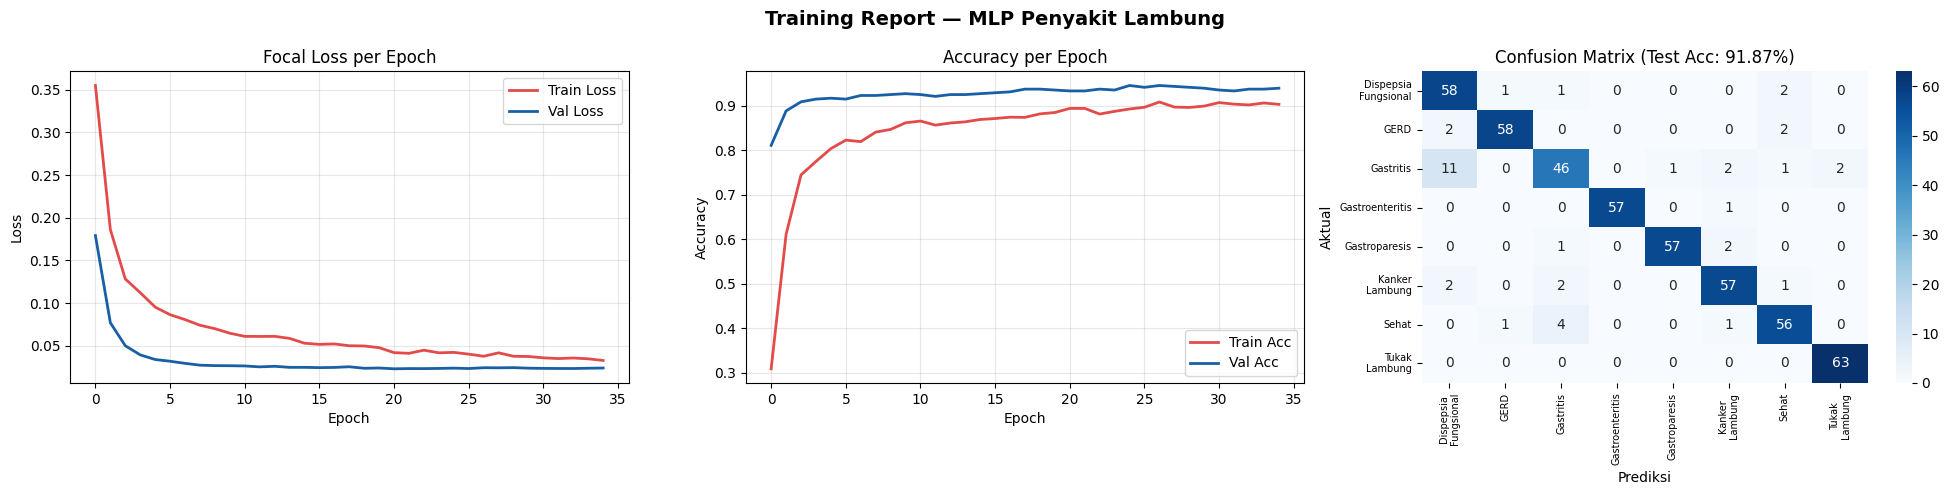

In [19]:
# Visualisasi hasil training────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Training Report — MLP Penyakit Lambung', fontsize=14, fontweight='bold')

hist = history.history
# Loss
axes[0].plot(hist['loss'],     label='Train Loss', color='#E24B4A', linewidth=2)
axes[0].plot(hist['val_loss'], label='Val Loss',   color='#185FA5', linewidth=2)
axes[0].set_title('Focal Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(hist['accuracy'],     label='Train Acc', color='#E24B4A', linewidth=2)
axes[1].plot(hist['val_accuracy'], label='Val Acc',   color='#185FA5', linewidth=2)
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=CLASSES)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
    xticklabels=[c.replace('_', '\n') for c in CLASSES],
    yticklabels=[c.replace('_', '\n') for c in CLASSES]
)
axes[2].set_title(f'Confusion Matrix (Test Acc: {acc_test*100:.2f}%)')
axes[2].set_xlabel('Prediksi'); axes[2].set_ylabel('Aktual')
axes[2].tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.savefig('training_report.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## [5b] Custom Training & Evaluation Loop — `tf.GradientTape`

Implementasi training loop **dari awal** tanpa `model.fit()`. Setiap langkah dikontrol penuh secara manual:

| Komponen | Detail |
|---|---|
| **Forward pass** | `tf.GradientTape` merekam operasi untuk autograd |
| **Loss** | `FocalLoss` kustom yang sudah didefinisikan di [2b] |
| **Backward pass** | `tape.gradient()` → `optimizer.apply_gradients()` |
| **Metrik** | `tf.keras.metrics` (Mean, Accuracy) di-reset tiap epoch |
| **Validation** | Loop evaluasi terpisah tanpa gradient (mode inferensi) |
| **EarlyStopping** | Implementasi manual berbasis `val_accuracy` |
| **LR Scheduler** | Cosine decay annealing via `tf.keras.optimizers.schedules` |
| **Checkpoint** | Simpan bobot terbaik via `model.get_weights()` |

In [20]:
# ================================================================
# [5b] CUSTOM TRAINING & EVALUATION LOOP — tf.GradientTape
# ================================================================
# Membangun ulang model baru (bobot fresh) khusus untuk
# demonstrasi custom loop — TIDAK menggantikan model dari [3]

print("=" * 60)
print("[5b] CUSTOM TRAINING LOOP — tf.GradientTape")
print("=" * 60)

# [5b-1] Hyperparameter──────────────────────────────────────
EPOCHS_CUSTOM   = 80          # maks epoch
BATCH_SIZE_CT   = 32
LR_INIT         = 5e-4        # learning rate awal
PATIENCE        = 10          # early stopping patience
MIN_DELTA       = 1e-4        # threshold perbaikan minimal

# [5b-2] tf.data.Dataset────────────────────────────────────
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train.astype('float32'), y_train.astype('int32')))
    .shuffle(buffer_size=len(X_train), seed=42)
    .batch(BATCH_SIZE_CT)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val.astype('float32'), y_val.astype('int32')))
    .batch(BATCH_SIZE_CT)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test.astype('float32'), y_test.astype('int32')))
    .batch(BATCH_SIZE_CT)
    .prefetch(tf.data.AUTOTUNE)
)

# [5b-3] Model & Optimizer baru (fresh weights)──────────────
model_ct = build_model(N_FEATURES, N_CLASSES, learning_rate=LR_INIT)

# Cosine Decay: LR turun halus dari LR_INIT → LR_INIT/10
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_INIT,
    decay_steps=EPOCHS_CUSTOM * (len(X_train) // BATCH_SIZE_CT),
    alpha=0.1,  # LR minimum = LR_INIT * alpha
)
optimizer_ct = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
loss_fn      = FocalLoss(gamma=2.0, alpha=0.25)

# [5b-4] Metrik tf.keras──────────────────────────────────────
train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
train_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy(name='train_acc')
val_loss_metric   = tf.keras.metrics.Mean(name='val_loss')
val_acc_metric    = tf.keras.metrics.SparseCategoricalAccuracy(name='val_acc')

# [5b-5] Satu Training Step (dikompilasi dengan tf.function)──
@tf.function
def train_step(x_batch, y_batch):
    """
    Forward + backward pass untuk satu batch.
    tf.GradientTape merekam semua operasi di dalam blok `with`
    sehingga gradient dapat dihitung secara otomatis.
    """
    with tf.GradientTape() as tape:
        # Forward pass — training=True mengaktifkan Dropout & BatchNorm
        y_pred = model_ct(x_batch, training=True)
        # Hitung loss (FocalLoss kustom)
        loss   = loss_fn(y_batch, y_pred)
        # Tambah regularization losses (mis. dari layer)
        loss  += tf.reduce_sum(model_ct.losses)

    # Backward pass: hitung gradien terhadap seluruh trainable weights
    gradients = tape.gradient(loss, model_ct.trainable_variables)

    # Gradient clipping: cegah exploding gradients
    gradients, _ = tf.clip_by_global_norm(gradients, clip_norm=1.0)

    # Update bobot: terapkan gradien ke optimizer
    optimizer_ct.apply_gradients(zip(gradients, model_ct.trainable_variables))

    # Update metrik
    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(y_batch, y_pred)

# [5b-6] Satu Validation Step────────────────────────────────
@tf.function
def val_step(x_batch, y_batch):
    """
    Evaluasi satu batch — TANPA GradientTape.
    training=False menonaktifkan Dropout dan memakai
    statistik running mean/var pada BatchNorm.
    """
    y_pred = model_ct(x_batch, training=False)
    loss   = loss_fn(y_batch, y_pred)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y_batch, y_pred)

# [5b-7] State Early Stopping & Checkpoint──────────────────
best_val_acc    = 0.0
best_weights    = None          # simpan bobot terbaik di RAM
patience_counter = 0
history_ct      = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

# [5b-8] Header tabel log─────────────────────────────────────
print(f"\n{'─'*70}")
print(f"{'Epoch':>6}  {'LR':>10}  {'Loss':>9}  {'Acc':>8}  "
      f"{'Val Loss':>9}  {'Val Acc':>8}  {'Status':>10}")
print(f"{'─'*70}")

# [5b-9] Training Loop Utama──────────────────────────────────
for epoch in range(1, EPOCHS_CUSTOM + 1):

    # ---- Reset semua metrik di awal epoch ----------------------
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()

    # ---- Training: iterasi semua batch -------------------------
    for x_batch, y_batch in train_ds:
        train_step(x_batch, y_batch)

    # ---- Validation: tanpa gradient ----------------------------
    for x_batch, y_batch in val_ds:
        val_step(x_batch, y_batch)

    # ---- Baca nilai metrik epoch ini ---------------------------
    t_loss = float(train_loss_metric.result())
    t_acc  = float(train_acc_metric.result())
    v_loss = float(val_loss_metric.result())
    v_acc  = float(val_acc_metric.result())

    # ---- Catat ke history --------------------------------------
    history_ct['loss'].append(t_loss)
    history_ct['accuracy'].append(t_acc)
    history_ct['val_loss'].append(v_loss)
    history_ct['val_accuracy'].append(v_acc)

    # ---- Learning rate saat ini --------------------------------
    current_lr = float(lr_schedule(optimizer_ct.iterations))

    # ---- Early Stopping & Checkpoint manual --------------------
    if v_acc > best_val_acc + MIN_DELTA:
        best_val_acc     = v_acc
        best_weights     = model_ct.get_weights()   # simpan bobot terbaik
        patience_counter = 0
        status = '✓ best'
    else:
        patience_counter += 1
        status = f'  -{patience_counter}'

    # ---- Cetak log setiap epoch --------------------------------
    print(f"{epoch:>6}  {current_lr:>10.6f}  {t_loss:>9.4f}  {t_acc:>8.4f}  "
          f"{v_loss:>9.4f}  {v_acc:>8.4f}  {status:>10}")

    # ---- Hentikan jika sudah tidak ada perbaikan ---------------
    if patience_counter >= PATIENCE:
        print(f"\n⏹  Early stopping dipicu di epoch {epoch} "
              f"(tidak ada perbaikan selama {PATIENCE} epoch berturut-turut).")
        break

# [5b-10] Kembalikan bobot terbaik ke model──────────────────
if best_weights is not None:
    model_ct.set_weights(best_weights)
    print(f"\n✓ Bobot terbaik dikembalikan (val_accuracy = {best_val_acc:.4f})")

[5b] CUSTOM TRAINING LOOP — tf.GradientTape

──────────────────────────────────────────────────────────────────────
 Epoch          LR       Loss       Acc   Val Loss   Val Acc      Status
──────────────────────────────────────────────────────────────────────
     1    0.000500     0.3443    0.2949     0.1775    0.7841      ✓ best
     2    0.000499     0.1786    0.6235     0.0849    0.8697      ✓ best
     3    0.000498     0.1324    0.7299     0.0592    0.9022      ✓ best
     4    0.000497     0.1066    0.7884     0.0475    0.9185      ✓ best
     5    0.000496     0.0932    0.8067     0.0397    0.9246      ✓ best
     6    0.000494     0.0861    0.8264     0.0363    0.9308      ✓ best
     7    0.000491     0.0812    0.8207     0.0335    0.9287          -1
     8    0.000489     0.0754    0.8312     0.0307    0.9369      ✓ best
     9    0.000486     0.0742    0.8346     0.0312    0.9267          -1
    10    0.000482     0.0672    0.8490     0.0309    0.9328          -2
    11    


[5b-11] EVALUASI — Custom Training Loop Model
[TB] Log dir → logs/custom_loop/20260602-162101
[TB] Loss & Accuracy per epoch → OK
[TB] Learning rate per epoch → OK

Test Loss     : 0.0367
Test Accuracy : 0.9045  (90.45%)
[TB] Test metrics → OK

Classification Report (Custom Loop):
                      precision    recall  f1-score   support

Dispepsia_Fungsional     0.8261    0.9194    0.8702        62
                GERD     0.9194    0.9194    0.9194        62
           Gastritis     0.7895    0.7143    0.7500        63
     Gastroenteritis     1.0000    0.9828    0.9913        58
       Gastroparesis     0.9492    0.9333    0.9412        60
      Kanker_Lambung     0.8615    0.9032    0.8819        62
               Sehat     0.9153    0.8710    0.8926        62
       Tukak_Lambung     0.9844    1.0000    0.9921        63

            accuracy                         0.9045       492
           macro avg     0.9057    0.9054    0.9048       492
        weighted avg     0.9046  

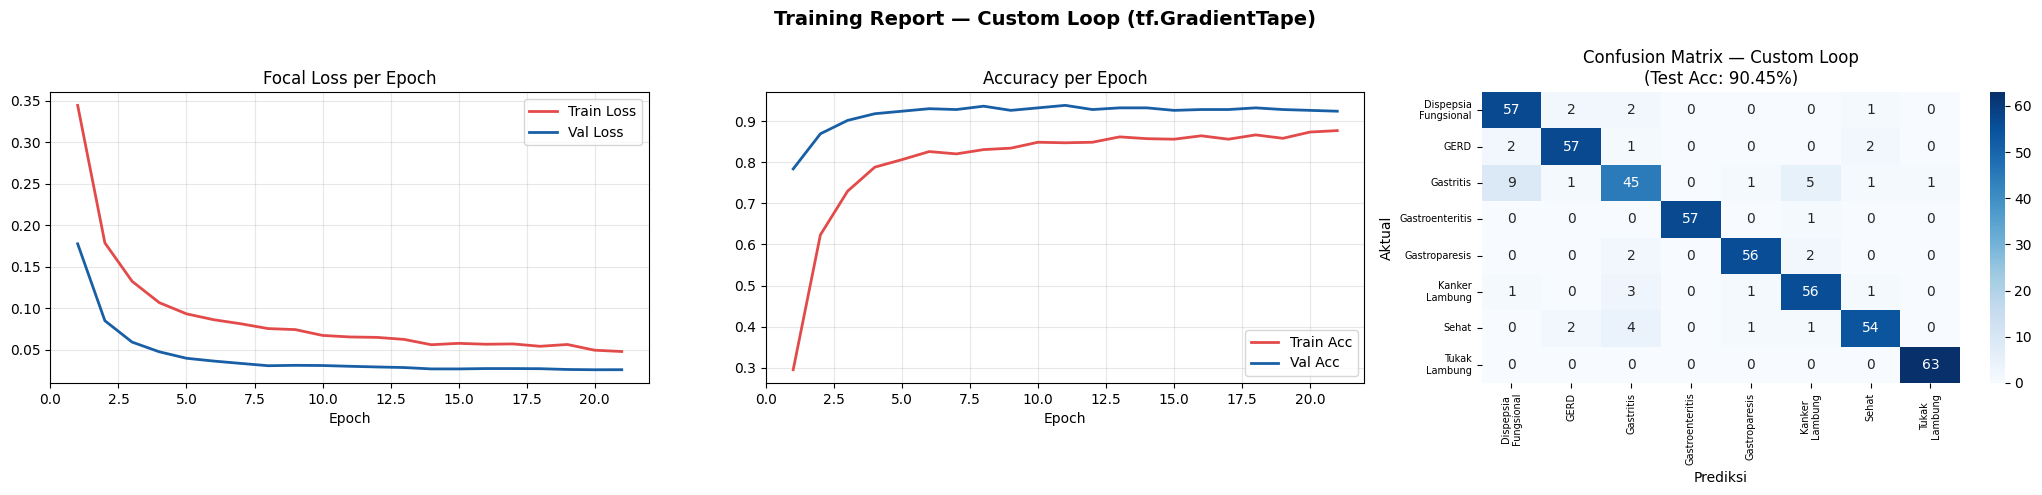

[VIZ] Chart tersimpan → training_report_custom_loop.png

PERBANDINGAN: model.fit  vs  Custom Loop (tf.GradientTape)
Metrik                  model.fit   Custom Loop
-----------------------------------------------
Test Accuracy              91.87%        90.45%
Test Loss                  0.0279        0.0367
Epochs dijalankan              35            21

CARA MEMBUKA TENSORBOARD
  Di terminal / Jupyter terminal:
    tensorboard --logdir=logs/custom_loop/20260602-162101

  Di dalam notebook (magic command):
    %load_ext tensorboard
    %tensorboard --logdir logs/custom_loop/20260602-162101

  Di Google Colab:
    %load_ext tensorboard
    %tensorboard --logdir logs/custom_loop/20260602-162101
[TB] Semua log tersimpan di → logs/custom_loop/20260602-162101


In [21]:
# ================================================================
# [5b-11] EVALUASI MODEL HASIL CUSTOM LOOP + TENSORBOARD LOGGING
# ================================================================
print("\n" + "=" * 60)
print("[5b-11] EVALUASI — Custom Training Loop Model")
print("=" * 60)

import itertools
import datetime

# [TB-1] Setup TensorBoard Writer───────────────────────────
log_dir    = "logs/custom_loop/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tb_writer  = tf.summary.create_file_writer(log_dir)
print(f"[TB] Log dir → {log_dir}")

# [TB-2] Log Loss & Accuracy per Epoch──────────────────────
# Tulis ulang seluruh history_ct ke TensorBoard
with tb_writer.as_default():
    for epoch_idx, (t_loss, t_acc, v_loss, v_acc) in enumerate(
        zip(history_ct['loss'], history_ct['accuracy'],
            history_ct['val_loss'], history_ct['val_accuracy']), start=1
    ):
        tf.summary.scalar("epoch/train_loss",     t_loss, step=epoch_idx)
        tf.summary.scalar("epoch/train_accuracy", t_acc,  step=epoch_idx)
        tf.summary.scalar("epoch/val_loss",       v_loss, step=epoch_idx)
        tf.summary.scalar("epoch/val_accuracy",   v_acc,  step=epoch_idx)
    tb_writer.flush()
print("[TB] Loss & Accuracy per epoch → OK")

# [TB-3] Log Learning Rate per Step─────────────────────────
# Rekonstruksi LR per epoch dari lr_schedule
total_steps_per_epoch = len(X_train) // BATCH_SIZE_CT
with tb_writer.as_default():
    for epoch_idx in range(1, len(history_ct['loss']) + 1):
        step_at_epoch = epoch_idx * total_steps_per_epoch
        lr_val = float(lr_schedule(step_at_epoch))
        tf.summary.scalar("epoch/learning_rate", lr_val, step=epoch_idx)
    tb_writer.flush()
print("[TB] Learning rate per epoch → OK")

# [TB-4] Evaluasi Test Set───────────────────────────────────
test_loss_metric = tf.keras.metrics.Mean()
test_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy()

@tf.function
def test_step(x_batch, y_batch):
    y_pred = model_ct(x_batch, training=False)
    loss   = loss_fn(y_batch, y_pred)
    test_loss_metric.update_state(loss)
    test_acc_metric.update_state(y_batch, y_pred)

for x_batch, y_batch in test_ds:
    test_step(x_batch, y_batch)

final_test_loss = float(test_loss_metric.result())
final_test_acc  = float(test_acc_metric.result())

print(f"\nTest Loss     : {final_test_loss:.4f}")
print(f"Test Accuracy : {final_test_acc:.4f}  ({final_test_acc*100:.2f}%)")

# Log test metrics ke TensorBoard
with tb_writer.as_default():
    tf.summary.scalar("test/loss",     final_test_loss, step=0)
    tf.summary.scalar("test/accuracy", final_test_acc,  step=0)
    tb_writer.flush()
print("[TB] Test metrics → OK")

# [TB-5] Classification Report──────────────────────────────
y_pred_ct        = np.argmax(model_ct.predict(X_test, verbose=0), axis=1)
y_pred_labels_ct = le.inverse_transform(y_pred_ct)
y_test_labels_ct = le.inverse_transform(y_test)

print("\nClassification Report (Custom Loop):")
print(classification_report(y_test_labels_ct, y_pred_labels_ct, digits=4))

# [TB-6] Helper: Figure → PNG tensor untuk TensorBoard───────
def fig_to_image_tensor(fig):
    """Konversi matplotlib Figure → uint8 tensor [1, H, W, 4]."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor='white')
    buf.seek(0)
    img = tf.image.decode_png(buf.getvalue(), channels=4)
    return tf.expand_dims(img, 0)  # [1, H, W, 4]

# [TB-7] Log Confusion Matrix sebagai Image───────────────────
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=[c.replace('_', '\n') for c in class_names],
        yticklabels=[c.replace('_', '\n') for c in class_names],
        linewidths=0.5
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    ax.tick_params(axis='both', labelsize=7)
    fig.tight_layout()
    return fig

cm_ct  = confusion_matrix(y_test_labels_ct, y_pred_labels_ct, labels=CLASSES)
fig_cm = plot_confusion_matrix(cm_ct, CLASSES,
             title=f"Confusion Matrix — Custom Loop (Test Acc: {final_test_acc*100:.2f}%)")

with tb_writer.as_default():
    tf.summary.image("confusion_matrix/custom_loop",
                     fig_to_image_tensor(fig_cm), step=0)
    tb_writer.flush()
plt.close(fig_cm)
print("[TB] Confusion matrix image → OK")

# [TB-8] Log Training Curves sebagai Image───────────────────
def plot_training_curves(history_dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training Curves — Custom Loop (tf.GradientTape)',
                 fontsize=13, fontweight='bold')
    epochs = range(1, len(history_dict['loss']) + 1)

    axes[0].plot(epochs, history_dict['loss'],     label='Train', color='#E24B4A', lw=2)
    axes[0].plot(epochs, history_dict['val_loss'], label='Val',   color='#185FA5', lw=2)
    axes[0].set_title('Focal Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history_dict['accuracy'],     label='Train', color='#E24B4A', lw=2)
    axes[1].plot(epochs, history_dict['val_accuracy'], label='Val',   color='#185FA5', lw=2)
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    fig.tight_layout()
    return fig

fig_curves = plot_training_curves(history_ct)
with tb_writer.as_default():
    tf.summary.image("training_curves/custom_loop",
                     fig_to_image_tensor(fig_curves), step=0)
    tb_writer.flush()
plt.close(fig_curves)
print("[TB] Training curves image → OK")

# [TB-9] Log Histogram Bobot Model───────────────────────────
with tb_writer.as_default():
    for var in model_ct.trainable_variables:
        # Ganti karakter tidak valid di nama variable
        tag = "weights/" + var.name.replace(":", "_")
        tf.summary.histogram(tag, var, step=0)
    tb_writer.flush()
print("[TB] Weight histograms → OK")

# [5b-11] Visualisasi Lokal (inline notebook)────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle('Training Report — Custom Loop (tf.GradientTape)',
             fontsize=14, fontweight='bold')

epochs = range(1, len(history_ct['loss']) + 1)
axes[0].plot(epochs, history_ct['loss'],     label='Train Loss', color='#E24B4A', lw=2)
axes[0].plot(epochs, history_ct['val_loss'], label='Val Loss',   color='#185FA5', lw=2)
axes[0].set_title('Focal Loss per Epoch'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_ct['accuracy'],     label='Train Acc', color='#E24B4A', lw=2)
axes[1].plot(epochs, history_ct['val_accuracy'], label='Val Acc',   color='#185FA5', lw=2)
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

sns.heatmap(
    cm_ct, annot=True, fmt='d', cmap='Blues', ax=axes[2],
    xticklabels=[c.replace('_', '\n') for c in CLASSES],
    yticklabels=[c.replace('_', '\n') for c in CLASSES]
)
axes[2].set_title(f'Confusion Matrix — Custom Loop\n(Test Acc: {final_test_acc*100:.2f}%)')
axes[2].set_xlabel('Prediksi'); axes[2].set_ylabel('Aktual')
axes[2].tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.savefig('training_report_custom_loop.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("[VIZ] Chart tersimpan → training_report_custom_loop.png")

# Perbandingan: model.fit vs custom loop─────────────────────
print("\n" + "=" * 60)
print("PERBANDINGAN: model.fit  vs  Custom Loop (tf.GradientTape)")
print("=" * 60)
print(f"{'Metrik':<20} {'model.fit':>12} {'Custom Loop':>13}")
print("-" * 47)
print(f"{'Test Accuracy':<20} {acc_test*100:>11.2f}% {final_test_acc*100:>12.2f}%")
print(f"{'Test Loss':<20} {loss_test:>12.4f} {final_test_loss:>13.4f}")
print(f"{'Epochs dijalankan':<20} {len(history.history['loss']):>12} {len(history_ct['loss']):>13}")

# [TB-10] Cara membuka TensorBoard───────────────────────────
print("\n" + "=" * 60)
print("CARA MEMBUKA TENSORBOARD")
print("=" * 60)
print(f"  Di terminal / Jupyter terminal:")
print(f"    tensorboard --logdir={log_dir}")
print(f"")
print(f"  Di dalam notebook (magic command):")
print(f"    %load_ext tensorboard")
print(f"    %tensorboard --logdir {log_dir}")
print(f"")
print(f"  Di Google Colab:")
print(f"    %load_ext tensorboard")
print(f"    %tensorboard --logdir {log_dir}")
print("=" * 60)
print(f"[TB] Semua log tersimpan di → {log_dir}")


In [22]:
# ================================================================
# [5b-12] MENYERTAKAN LOG TENSORBOARD DALAM REPOSITORY
# ================================================================
# Tugas: "menyertakan log yang dihasilkan dalam repository akhir"
# Strategi:
#   1. Gabungkan semua log (model.fit + custom loop) ke satu folder
#   2. Zip folder logs/ → logs_tensorboard.zip
#   3. Instruksi git untuk commit log ke repo

import os, shutil, zipfile, glob

print("=" * 60)
print("[5b-12] MENGARSIPKAN LOG TENSORBOARD → REPOSITORY")
print("=" * 60)

# Verifikasi log dirs yang sudah dibuat──────────────────────
log_dirs = {
    "model.fit  ": tb_log_dir_fit,   # dari cell [4] callbacks
    "custom loop": log_dir,           # dari cell [5b-11]
}

print("\nLog directories yang dihasilkan:")
for label, ldir in log_dirs.items():
    exists = os.path.isdir(ldir)
    n_files = sum(len(f) for _, _, f in os.walk(ldir)) if exists else 0
    print(f"  [{'✓' if exists else '✗'}] {label}  →  {ldir}  ({n_files} file)")

# Zip seluruh folder logs/ → satu file arsip────────────────
zip_path = "logs_tensorboard.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk("logs/"):
        for file in files:
            full_path = os.path.join(root, file)
            arcname   = os.path.relpath(full_path, start=".")
            zf.write(full_path, arcname)

zip_size_kb = os.path.getsize(zip_path) / 1024
print(f"\n[ZIP] {zip_path}  →  {zip_size_kb:.1f} KB")

# Tampilkan struktur isi ZIP─────────────────────────────────
print("\nStruktur log dalam ZIP:")
with zipfile.ZipFile(zip_path, 'r') as zf:
    entries = sorted(zf.namelist())
    for entry in entries[:30]:   # tampilkan maks 30 baris
        size = zf.getinfo(entry).file_size
        print(f"  {entry:<60} {size:>8,} B")
    if len(entries) > 30:
        print(f"  ... dan {len(entries)-30} file lainnya")

print(f"\nTotal: {len(entries)} file dalam arsip")

# Instruksi Git untuk commit log ke repository───────────────
print("\n" + "=" * 60)
print("INSTRUKSI: Menyertakan log dalam Git Repository")
print("=" * 60)
print("""
OPSI A — Commit folder logs/ langsung (disarankan untuk Colab/lokal):
───────────────────────────
  # 1. Pastikan logs/ tidak ada di .gitignore
  #    (hapus baris "logs/" dari .gitignore jika ada)

  git add logs/
  git add logs_tensorboard.zip
  git commit -m "Add TensorBoard logs (model.fit + custom GradientTape loop)"
  git push

OPSI B — Hanya zip (untuk ukuran repo lebih kecil):
───────────────────────────
  git add logs_tensorboard.zip
  git commit -m "Add TensorBoard logs archive"
  git push

OPSI C — GitHub Actions / CI pipeline (otomatis):
───────────────────────────
  # Tambahkan ke workflow .github/workflows/train.yml:
  - name: Upload TensorBoard logs
    uses: actions/upload-artifact@v3
    with:
      name: tensorboard-logs
      path: logs/

CARA MEMBUKA LOG SETELAH CLONE:
───────────────────────────
  # Dari folder logs/ langsung:
  tensorboard --logdir=logs/

  # Atau arahkan ke sub-folder spesifik:
  tensorboard --logdir=logs/model_fit/       # training model.fit
  tensorboard --logdir=logs/custom_loop/     # custom GradientTape loop

  # Bandingkan keduanya sekaligus di satu dashboard:
  tensorboard --logdir_spec=fit:logs/model_fit,custom:logs/custom_loop/
""")

print(f"[REPO] Log siap disertakan dalam repository.")
print(f"       File arsip → {os.path.abspath(zip_path)}")


[5b-12] MENGARSIPKAN LOG TENSORBOARD → REPOSITORY

Log directories yang dihasilkan:
  [✓] model.fit    →  logs/model_fit/20260602-161921  (2 file)
  [✓] custom loop  →  logs/custom_loop/20260602-162101  (1 file)

[ZIP] logs_tensorboard.zip  →  502.4 KB

Struktur log dalam ZIP:
  logs/custom_loop/20260602-162101/events.out.tfevents.1780417261.21ca2c9af330.2495.2.v2  134,495 B
  logs/model_fit/20260602-161921/train/events.out.tfevents.1780417162.21ca2c9af330.2495.0.v2 1,203,627 B
  logs/model_fit/20260602-161921/validation/events.out.tfevents.1780417189.21ca2c9af330.2495.1.v2   11,272 B

Total: 3 file dalam arsip

INSTRUKSI: Menyertakan log dalam Git Repository

OPSI A — Commit folder logs/ langsung (disarankan untuk Colab/lokal):
───────────────────────────
  # 1. Pastikan logs/ tidak ada di .gitignore
  #    (hapus baris "logs/" dari .gitignore jika ada)

  git add logs/
  git add logs_tensorboard.zip
  git commit -m "Add TensorBoard logs (model.fit + custom GradientTape loop)"
  git p

#Simpan Model - Format .keras

In [23]:
print("\n" + "="*60)
print("[6] SIMPAN MODEL")
print("="*60)

# Model sudah tersimpan via ModelCheckpoint, simpan sekali lagi eksplisit
model_best.save('model_lambung.keras')
print("✓ model_lambung.keras  — TF Keras format (produksi)")

# Simpan juga dalam format SavedModel (opsional, untuk TF Serving)
model_best.export('model_lambung_savedmodel')
print("✓ model_lambung_savedmodel/ — SavedModel format")


[6] SIMPAN MODEL
✓ model_lambung.keras  — TF Keras format (produksi)
Saved artifact at 'model_lambung_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 31), dtype=tf.float32, name='input_gejala')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  134207845070608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845070032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845069456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845057744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845069648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845060624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845071952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845068496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845068688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134207845069840

#Inference

In [24]:
print("\n" + "="*60)
print("[7] CONTOH INFERENCE")
print("="*60)

# Konstanta penting untuk inference
FITUR_DASAR = [
    'nyeri_ulu_hati', 'mual', 'muntah', 'kembung', 'heartburn',
    'asam_naik_tenggorokan', 'diare', 'demam', 'penurunan_berat_badan',
    'cepat_kenyang', 'muntah_tak_tercerna', 'nyeri_perut_kosong',
    'feses_hitam', 'riwayat_nsaid', 'stres_tinggi', 'batuk_kronis',
    'suara_serak', 'anemia_lemas', 'nafsu_makan_hilang', 'nyeri_dada'
]

def preprocess_input(jawaban: dict) -> np.ndarray:
    """
    Konversi jawaban kuesioner → array siap inferensi.
    Langkah:
      1. Imputasi nilai yang hilang (modus per kelas dari train)
      2. Feature engineering (interaction features)
      3. Scaling (StandardScaler dari train)
    """
    # Isi nilai yang kosong dengan modus global (kelas default: Sehat)
    f = {}
    for col in FITUR_DASAR:
        val = jawaban.get(col, None)
        if val is None:
            # Fallback: modus dari kelas 'Sehat'
            f[col] = impute_map[col].get('Sehat', 0)
        else:
            f[col] = int(val)

    # Feature Engineering (harus sama persis dengan saat training)
    f['gejala_refluks']    = int(f['heartburn'] >= 1 and f['asam_naik_tenggorokan'] >= 1)
    f['gejala_ulkus']      = int(f['nyeri_perut_kosong'] >= 1 and f['feses_hitam'] >= 1)
    f['gejala_infeksi']    = int(f['diare'] >= 1 and f['demam'] >= 1)
    f['gejala_kanker']     = int(f['penurunan_berat_badan'] >= 1 and
                                  f['anemia_lemas'] >= 1 and
                                  f['nafsu_makan_hilang'] >= 1)
    f['gejala_motilitas']  = int(f['muntah_tak_tercerna'] >= 1 and f['cepat_kenyang'] >= 1)
    f['gejala_fungsional'] = int(f['kembung'] >= 1 and f['stres_tinggi'] >= 1)
    f['total_gejala']      = sum(f[k] for k in FITUR_DASAR)

        # === TAMBAHAN FITUR BARU ===
    f['skor_gerd'] = (
        f['heartburn']*2 +
        f['asam_naik_tenggorokan']*2 +
        f['nyeri_dada']
    )

    f['skor_gastritis'] = (
        f['nyeri_ulu_hati'] +
        f['mual'] +
        f['kembung']
    )

    f['skor_kanker'] = (
        f['penurunan_berat_badan']*2 +
        f['anemia_lemas']*2 +
        f['nafsu_makan_hilang']*2
    )

    f['skor_infeksi'] = f['diare'] + f['demam']

    # Susun array sesuai urutan fitur training
    x = np.array([[f[k] for k in FITUR_FINAL]], dtype=np.float32)
    return scaler.transform(x)


def predict(jawaban: dict) -> dict:
    """
    Prediksi penyakit dari jawaban kuesioner.

    Args:
        jawaban : dict {nama_fitur: nilai (0-3)}

    Returns:
        dict berisi prediksi, probabilitas, dan top-3
    """
    X_input = preprocess_input(jawaban)
    proba   = model_best.predict(X_input, verbose=0)[0]
    idx     = int(np.argmax(proba))
    kelas   = le.inverse_transform([idx])[0]

    top3 = sorted(
        [{'kelas': le.inverse_transform([i])[0], 'prob': float(proba[i])}
         for i in range(len(proba))],
        key=lambda x: x['prob'], reverse=True
    )[:3]

    return {
        'prediksi'   : kelas,
        'kepercayaan': f"{proba[idx]*100:.1f}%",
        'top3'       : top3,
        'all_proba'  : {le.inverse_transform([i])[0]: float(proba[i])
                        for i in range(len(proba))}
    }


# Contoh prediksi GERD
contoh_gerd = {
    'nyeri_ulu_hati': 2, 'mual': 1, 'muntah': 0, 'kembung': 1,
    'heartburn': 1, 'asam_naik_tenggorokan': 1, 'diare': 0, 'demam': 0,
    'penurunan_berat_badan': 0, 'cepat_kenyang': 0, 'muntah_tak_tercerna': 0,
    'nyeri_perut_kosong': 0, 'feses_hitam': 0, 'riwayat_nsaid': 0,
    'stres_tinggi': 1, 'batuk_kronis': 1, 'suara_serak': 1,
    'anemia_lemas': 0, 'nafsu_makan_hilang': 0, 'nyeri_dada': 1,
}
hasil = predict(contoh_gerd)
print(f"\nContoh prediksi kasus GERD:")
print(f"  Prediksi    : {hasil['prediksi']}")
print(f"  Kepercayaan : {hasil['kepercayaan']}")
print(f"  Top-3       :")
for t in hasil['top3']:
    print(f"    {t['kelas']:<25} {t['prob']*100:.1f}%")

# Contoh prediksi SEHAT
contoh_sehat = {k: 0 for k in FITUR_DASAR}
hasil_sehat  = predict(contoh_sehat)
print(f"\nContoh prediksi input kosong (seharusnya Sehat):")
print(f"  Prediksi    : {hasil_sehat['prediksi']}")
print(f"  Kepercayaan : {hasil_sehat['kepercayaan']}")


[7] CONTOH INFERENCE

Contoh prediksi kasus GERD:
  Prediksi    : GERD
  Kepercayaan : 85.1%
  Top-3       :
    GERD                      85.1%
    Sehat                     4.4%
    Dispepsia_Fungsional      3.2%

Contoh prediksi input kosong (seharusnya Sehat):
  Prediksi    : Sehat
  Kepercayaan : 94.0%


#Explanatory Analysis

Tahap explanatory analysis dilakukan untuk menjawab pertanyaan bisnis yang telah ditentukan pada pengembangan GastroCare. Analisis dilakukan menggunakan data training agar pola yang ditemukan dapat digunakan sebagai dasar dalam pembangunan model machine learning.

Analisis difokuskan pada tiga aspek utama:

1. Distribusi penyakit lambung pada dataset.
2. Pola gejala yang paling dominan.
3. Performa model machine learning dalam klasifikasi penyakit lambung.

**Business Question 1**

Bagaimana distribusi penyakit lambung berdasarkan data pasien pada sistem GastroCare selama periode pengujian dataset?

Analisis dilakukan untuk mengetahui penyakit yang paling dominan pada dataset GastroCare. Informasi ini penting untuk memahami karakteristik data dan mengevaluasi apakah terdapat ketidakseimbangan kelas yang dapat memengaruhi performa model.

In [25]:
# Distribusi penyakit pada train set

disease_distribution = (
    pd.Series(le.inverse_transform(y_train))
    .value_counts()
    .reset_index()
)

disease_distribution.columns = [
    "Disease",
    "Count"
]

display(disease_distribution)

max_count = disease_distribution["Count"].max()

top_diseases = disease_distribution[
    disease_distribution["Count"] == max_count
]["Disease"].tolist()

print(
    f"Penyakit dengan jumlah kasus tertinggi adalah "
    f"{', '.join(top_diseases)} "
    f"dengan {max_count} kasus."
)

,Disease,Count
0,Gastritis,293
1,Tukak_Lambung,293
2,Sehat,291
3,GERD,288
4,Dispepsia_Fungsional,288
5,Kanker_Lambung,286
6,Gastroparesis,281
7,Gastroenteritis,272


Penyakit dengan jumlah kasus tertinggi adalah Gastritis, Tukak_Lambung dengan 293 kasus.


**Insight**

Berdasarkan distribusi kelas pada data pelatihan, ditemukan bahwa **Gastritis** dan **Tukak Lambung** merupakan penyakit dengan jumlah kasus tertinggi pada dataset GastroCare, masing-masing sebanyak **293 kasus**.

Temuan ini menunjukkan bahwa pola gejala yang berkaitan dengan kedua penyakit tersebut lebih sering muncul dibandingkan kategori penyakit lainnya pada data yang digunakan untuk pengembangan sistem.

Selain itu, distribusi kelas yang relatif seimbang antar penyakit membantu model machine learning mempelajari karakteristik setiap kelas dengan lebih baik dan mengurangi risiko bias terhadap penyakit tertentu.

**Business** Question 2

Gejala apa yang paling dominan dan memiliki hubungan tertinggi terhadap hasil prediksi penyakit lambung pada GastroCare selama proses analisis data?

Analisis dilakukan menggunakan prevalensi gejala pada data training serta pola hubungan gejala terhadap masing-masing penyakit melalui heatmap rata-rata intensitas gejala.

In [26]:
# Top gejala berdasarkan prevalensi

symptom_prevalence = (
    df_train_valid[FITUR_BINER]
    .mean()
    .sort_values(ascending=False)
)

display(
    symptom_prevalence
    .head(10)
    .to_frame("Prevalence")
)

,Prevalence
mual,0.646833
nafsu_makan_hilang,0.518234
muntah,0.512476
cepat_kenyang,0.491363
kembung,0.439539
nyeri_dada,0.401152
anemia_lemas,0.399232
penurunan_berat_badan,0.341651
stres_tinggi,0.339731
heartburn,0.335893


In [27]:
top_symptoms = (
    symptom_prevalence
    .head(3)
    .index
    .tolist()
)

print("Top 3 Gejala:")
for i, symptom in enumerate(top_symptoms, start=1):
    print(f"{i}. {symptom}")

Top 3 Gejala:
1. mual
2. nafsu_makan_hilang
3. muntah


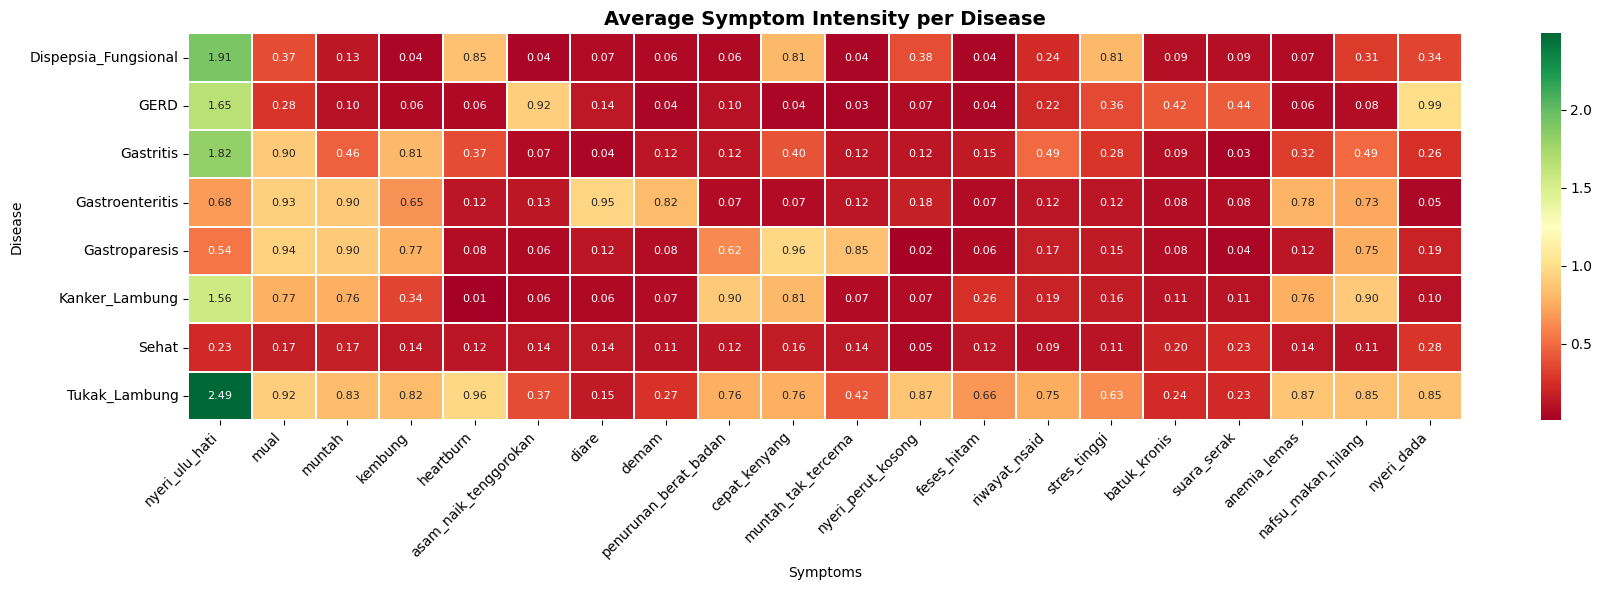

In [28]:
# Heatmap rata-rata intensitas gejala per penyakit

symptom_relationship = (
    df_train_valid
    .groupby(LABEL)[FITUR_SEMUA]
    .mean()
    .round(2)
)

plt.figure(figsize=(18, 6))

sns.heatmap(
    symptom_relationship,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.3,
    annot_kws={"size": 8}
)

plt.title(
    "Average Symptom Intensity per Disease",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Symptoms")
plt.ylabel("Disease")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
# Rata-rata intensitas gejala per penyakit

display(symptom_relationship)

,nyeri_ulu_hati,mual,muntah,kembung,heartburn,asam_naik_tenggorokan,diare,demam,penurunan_berat_badan,cepat_kenyang,muntah_tak_tercerna,nyeri_perut_kosong,feses_hitam,riwayat_nsaid,stres_tinggi,batuk_kronis,suara_serak,anemia_lemas,nafsu_makan_hilang,nyeri_dada
label,,,,,,,,,,,,,,,,,,,,
Dispepsia_Fungsional,1.91,0.37,0.13,0.04,0.85,0.04,0.07,0.06,0.06,0.81,0.04,0.38,0.04,0.24,0.81,0.09,0.09,0.07,0.31,0.34
GERD,1.65,0.28,0.10,0.06,0.06,0.92,0.14,0.04,0.10,0.04,0.03,0.07,0.04,0.22,0.36,0.42,0.44,0.06,0.08,0.99
Gastritis,1.82,0.90,0.46,0.81,0.37,0.07,0.04,0.12,0.12,0.40,0.12,0.12,0.15,0.49,0.28,0.09,0.03,0.32,0.49,0.26
Gastroenteritis,0.68,0.93,0.90,0.65,0.12,0.13,0.95,0.82,0.07,0.07,0.12,0.18,0.07,0.12,0.12,0.08,0.08,0.78,0.73,0.05
Gastroparesis,0.54,0.94,0.90,0.77,0.08,0.06,0.12,0.08,0.62,0.96,0.85,0.02,0.06,0.17,0.15,0.08,0.04,0.12,0.75,0.19
Kanker_Lambung,1.56,0.77,0.76,0.34,0.01,0.06,0.06,0.07,0.90,0.81,0.07,0.07,0.26,0.19,0.16,0.11,0.11,0.76,0.90,0.10
Sehat,0.23,0.17,0.17,0.14,0.12,0.14,0.14,0.11,0.12,0.16,0.14,0.05,0.12,0.09,0.11,0.20,0.23,0.14,0.11,0.28
Tukak_Lambung,2.49,0.92,0.83,0.82,0.96,0.37,0.15,0.27,0.76,0.76,0.42,0.87,0.66,0.75,0.63,0.24,0.23,0.87,0.85,0.85


Catatan:
Nilai rata-rata pada visualisasi symptom relationship merupakan hasil agregasi rata-rata gejala dari tingkat keparahan gejala pada masing-masing penyakit.

Karena menggunakan nilai rata-rata, maka hasil visualisasi dapat berupa bilangan desimal atau nilai di atas 1, meskipun data asli pasien menggunakan skala ordinal 0–3.

**Insight**

Berdasarkan analisis prevalensi gejala pada data pelatihan, ditemukan bahwa **mual**, **nafsu makan hilang**, dan **muntah** merupakan tiga gejala yang paling sering muncul pada pasien. Temuan ini menunjukkan bahwa gangguan pencernaan merupakan karakteristik umum yang ditemukan pada berbagai penyakit lambung dalam dataset GastroCare.

Analisis hubungan gejala terhadap penyakit melalui heatmap menunjukkan bahwa setiap penyakit memiliki pola gejala yang berbeda. GERD memiliki hubungan yang kuat dengan gejala asam naik ke tenggorokan dan nyeri dada, sedangkan Gastritis lebih sering dikaitkan dengan mual dan kembung. Gastroenteritis didominasi oleh diare, muntah, dan demam yang mencerminkan proses infeksi saluran cerna.

Selain itu, Gastroparesis menunjukkan prevalensi tinggi pada gejala cepat kenyang dan muntah makanan yang tidak tercerna, sementara Kanker Lambung memiliki hubungan kuat dengan penurunan berat badan, hilangnya nafsu makan, dan anemia. Perbedaan pola gejala ini menunjukkan bahwa kombinasi gejala memberikan informasi yang penting dalam membedakan berbagai jenis penyakit lambung.

Temuan tersebut mendukung penggunaan pendekatan machine learning pada GastroCare karena model dapat memanfaatkan pola hubungan antar gejala untuk meningkatkan akurasi klasifikasi penyakit.

**Business** Question 3

Bagaimana performa model machine learning GastroCare dalam mengklasifikasikan penyakit lambung berdasarkan data gejala pasien selama proses evaluasi model?

Evaluasi dilakukan menggunakan metrik klasifikasi untuk mengukur kemampuan model dalam memprediksi penyakit berdasarkan gejala pasien.

In [30]:
#Metrik evaluasi

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

evaluation_result = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(evaluation_result)

NameError: name 'accuracy_score' is not defined

In [ ]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

class_names = le.classes_

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Insight**

Model GastroCare menunjukkan performa yang sangat baik dalam mengklasifikasikan penyakit lambung berdasarkan gejala pasien.

Hasil evaluasi pada data uji menunjukkan nilai Accuracy sebesar 91.46%, yang berarti model mampu mengklasifikasikan sekitar 9 dari 10 pasien dengan benar.

Selain itu, model memperoleh Precision sebesar 91.68%, Recall sebesar 91.46%, dan F1-Score sebesar 91.37%. Nilai yang relatif seimbang pada ketiga metrik tersebut menunjukkan bahwa model tidak hanya akurat, tetapi juga mampu mempertahankan kualitas prediksi pada seluruh kategori penyakit.

Berdasarkan confusion matrix, sebagian besar sampel berhasil diprediksi pada kelas yang benar. Kesalahan prediksi paling banyak terjadi pada kelas Gastritis yang memiliki karakteristik gejala yang mirip dengan beberapa penyakit lambung lainnya. Namun secara keseluruhan, model telah mampu mempelajari pola hubungan gejala dan penyakit dengan baik.

Dengan performa di atas 90%, model GastroCare layak digunakan sebagai dasar sistem pendukung keputusan untuk membantu proses identifikasi awal penyakit lambung berdasarkan gejala pasien.

## Conclusion

Berdasarkan hasil exploratory data analysis dan evaluasi model pada sistem GastroCare, diperoleh beberapa temuan utama yang menjawab seluruh business question yang telah ditetapkan.

1. Disease Distribution Analysis

Analisis distribusi penyakit menunjukkan bahwa data pelatihan memiliki distribusi kelas yang relatif seimbang. Penyakit dengan jumlah kasus tertinggi adalah Gastritis dan Tukak Lambung, masing-masing sebanyak 293 kasus, sedangkan Gastroenteritis memiliki jumlah kasus paling rendah dengan 272 kasus. Distribusi yang seimbang membantu model mempelajari pola setiap penyakit secara lebih optimal dan mengurangi risiko bias terhadap kelas tertentu.

2. Symptom Pattern Analysis

Hasil analisis prevalensi gejala menunjukkan bahwa mual, nafsu makan hilang, dan muntah merupakan gejala yang paling sering muncul pada dataset. Selain itu, heatmap rata-rata intensitas gejala menunjukkan bahwa setiap penyakit memiliki pola gejala yang khas. Sebagai contoh, GERD memiliki hubungan kuat dengan gejala refluks seperti asam naik ke tenggorokan dan nyeri dada, sedangkan Tukak Lambung ditandai oleh tingginya intensitas nyeri ulu hati, heartburn, dan nyeri perut kosong. Temuan ini menunjukkan bahwa kombinasi gejala memiliki peran penting dalam proses klasifikasi penyakit lambung.

3. Machine Learning Performance Analysis

Model machine learning yang digunakan pada GastroCare menunjukkan performa yang sangat baik dengan nilai Accuracy sebesar 91.46%, Precision sebesar 91.68%, Recall sebesar 91.46%, dan F1-Score sebesar 91.37%. Hasil confusion matrix menunjukkan bahwa sebagian besar kasus berhasil diklasifikasikan dengan benar. Kesalahan prediksi yang masih muncul umumnya terjadi pada penyakit yang memiliki karakteristik gejala yang mirip, seperti Gastritis, Dispepsia Fungsional, dan Tukak Lambung.


**KESIMPULAN AKHIR**

Secara keseluruhan, sistem GastroCare berhasil mengidentifikasi pola gejala yang berkaitan dengan berbagai penyakit lambung serta mampu melakukan klasifikasi penyakit dengan tingkat performa yang tinggi. Analisis data menunjukkan bahwa gejala-gejala utama dapat digunakan sebagai indikator penting dalam proses diagnosis awal, sementara hasil evaluasi model membuktikan bahwa pendekatan machine learning yang digunakan sudah cukup andal untuk mendukung proses klasifikasi penyakit lambung berdasarkan gejala pasien.

#Gradio APP

In [ ]:
# ================================================================
print("\n" + "="*60)
print("[8] GRADIO APP")
print("="*60)

In [ ]:
# Skala kata → angka 0-3───────────────────────────────────
SKALA_INTENSITAS = ["Tidak sama sekali", "Ringan", "Sedang", "Berat / Sangat parah"]
SKALA_FREKUENSI  = ["Tidak pernah", "Kadang-kadang", "Sering", "Hampir selalu"]
SKALA_YA_TIDAK   = ["Tidak", "Ya, sedikit", "Ya, cukup signifikan", "Ya, sangat signifikan"]

PERTANYAAN = [
    ('nyeri_ulu_hati',
     '1. Seberapa parah rasa nyeri atau tidak nyaman di ulu hati Anda\n(bagian tengah-atas perut)?',
     SKALA_INTENSITAS),
    ('mual',
     '2. Seberapa sering Anda merasa mual (ingin muntah tanpa sebab jelas)?',
     SKALA_FREKUENSI),
    ('muntah',
     '3. Seberapa sering Anda benar-benar muntah?',
     SKALA_FREKUENSI),
    ('kembung',
     '4. Seberapa sering perut Anda terasa kembung, begah, atau penuh berlebihan?',
     SKALA_FREKUENSI),
    ('heartburn',
     '5. Seberapa sering Anda merasakan sensasi panas atau terbakar di dada (heartburn)?',
     SKALA_FREKUENSI),
    ('asam_naik_tenggorokan',
     '6. Seberapa sering ada rasa asam atau pahit yang naik ke tenggorokan atau mulut Anda?',
     SKALA_FREKUENSI),
    ('diare',
     '7. Seberapa sering Anda mengalami diare (BAB cair lebih dari 3x sehari)?',
     SKALA_FREKUENSI),
    ('demam',
     '8. Seberapa parah demam yang Anda rasakan belakangan ini?',
     SKALA_INTENSITAS),
    ('penurunan_berat_badan',
     '9. Apakah berat badan Anda turun tanpa sedang menjalani program diet?',
     SKALA_YA_TIDAK),
    ('cepat_kenyang',
     '10. Seberapa sering Anda merasa sangat cepat kenyang meski baru makan sedikit?',
     SKALA_FREKUENSI),
    ('muntah_tak_tercerna',
     '11. Seberapa sering Anda muntah makanan yang tampak belum tercerna (bukan cairan)?',
     SKALA_FREKUENSI),
    ('nyeri_perut_kosong',
     '12. Seberapa sering nyeri perut terasa lebih parah justru saat perut kosong?',
     SKALA_FREKUENSI),
    ('feses_hitam',
     '13. Apakah Anda pernah melihat feses berwarna hitam pekat seperti ter?',
     ['Tidak pernah', 'Pernah sekali', 'Beberapa kali dalam sebulan', 'Sering / hampir setiap hari']),
    ('riwayat_nsaid',
     '14. Seberapa rutin Anda mengonsumsi ibuprofen, aspirin, atau obat antiinflamasi?',
     ['Tidak pernah', 'Sesekali (< 1x/minggu)', 'Cukup rutin (1–3x/minggu)', 'Sangat rutin (hampir setiap hari)']),
    ('stres_tinggi',
     '15. Seberapa sering gejala perut Anda terasa memburuk saat stres atau cemas?',
     SKALA_FREKUENSI),
    ('batuk_kronis',
     '16. Seberapa sering Anda mengalami batuk tiba-tiba, terutama malam hari atau setelah makan?',
     SKALA_FREKUENSI),
    ('suara_serak',
     '17. Seberapa sering suara Anda terasa serak tanpa sebab yang jelas?',
     SKALA_FREKUENSI),
    ('anemia_lemas',
     '18. Seberapa sering Anda merasa sangat lemas atau pernah didiagnosis anemia?',
     SKALA_FREKUENSI),
    ('nafsu_makan_hilang',
     '19. Seberapa signifikan penurunan nafsu makan yang Anda rasakan belakangan ini?',
     SKALA_INTENSITAS),
    ('nyeri_dada',
     '20. Seberapa sering Anda merasakan nyeri atau tekanan di area dada?',
     SKALA_FREKUENSI),
]

In [ ]:
# Info per kelas untuk tampilan hasil──────────────────────
CLASS_INFO = {
    'Sehat': {
        'icon': '✅', 'tingkat': 'Normal',
        'deskripsi': 'Tidak ada pola gejala yang khas untuk penyakit lambung tertentu.',
        'saran': 'Pertahankan pola makan sehat dan gaya hidup aktif.'
    },
    'Gastritis': {
        'icon': '🟡', 'tingkat': 'Sedang',
        'deskripsi': 'Peradangan pada lapisan lambung. Sering dipicu NSAID, alkohol, atau H. pylori.',
        'saran': 'Hindari alkohol, obat NSAID tanpa resep, dan makanan pedas. Konsultasi dokter.'
    },
    'Tukak_Lambung': {
        'icon': '🟠', 'tingkat': 'Berat',
        'deskripsi': 'Luka terbuka pada lapisan lambung akibat erosi asam berlebih.',
        'saran': '⚠️ Segera ke dokter. Perlu endoskopi dan kemungkinan antibiotik (H. pylori).'
    },
    'GERD': {
        'icon': '🟡', 'tingkat': 'Sedang',
        'deskripsi': 'Asam lambung naik ke kerongkongan karena katup (LES) melemah.',
        'saran': 'Hindari makan 3 jam sebelum tidur, kurangi kafein dan makanan berlemak.'
    },
    'Dispepsia_Fungsional': {
        'icon': '🟢', 'tingkat': 'Ringan',
        'deskripsi': 'Gangguan pencernaan tanpa kerusakan fisik nyata. Dipengaruhi stres.',
        'saran': 'Kelola stres, makan teratur porsi kecil, hindari makanan pemicu.'
    },
    'Gastroparesis': {
        'icon': '🟠', 'tingkat': 'Berat',
        'deskripsi': 'Lambung tidak bisa mengosongkan isinya secara normal.',
        'saran': '⚠️ Konsultasi segera. Makan porsi kecil dan sering, hindari lemak tinggi.'
    },
    'Gastroenteritis': {
        'icon': '🟡', 'tingkat': 'Sedang',
        'deskripsi': 'Infeksi virus/bakteri pada lambung dan usus (flu perut).',
        'saran': 'Perbanyak cairan/oralit. Ke dokter jika gejala > 2 hari atau ada darah.'
    },
    'Kanker_Lambung': {
        'icon': '🔴', 'tingkat': 'Kritis',
        'deskripsi': 'Kemungkinan pertumbuhan sel abnormal di lambung.',
        'saran': '🚨 SEGERA ke dokter spesialis. Diperlukan endoskopi dan pemeriksaan lanjutan.'
    },
}

def predict_gradio(*args):
    """Fungsi prediksi untuk Gradio — terima jawaban kata-kata, return dict probabilitas."""
    input_keys = [k for k, _, _ in PERTANYAAN]
    skala_list = [s for _, _, s in PERTANYAAN]

    jawaban = {}
    for i, key in enumerate(input_keys):
        pilihan = args[i]
        if pilihan is None:
            return {kls: 0.0 for kls in CLASSES}
        jawaban[key] = skala_list[i].index(pilihan)

    hasil  = predict(jawaban)
    proba  = hasil['all_proba']
    kelas  = hasil['prediksi']
    conf   = float(hasil['kepercayaan'].replace('%', ''))

    # Jika confidence < 40% dan bukan Sehat → tambah warning
    if conf < 40.0 and kelas != 'Sehat':
        proba[f'⚠️ Confidence rendah ({conf:.0f}%) — gejala tidak khas'] = 0.001

    return proba

In [ ]:
# Build Gradio UI───
CSS = """
.pertanyaan label { font-weight: 600 !important; font-size: 0.88rem !important; }
footer { display: none !important; }
"""

with gr.Blocks(theme=gr.themes.Soft(), css=CSS, title="Deteksi Penyakit Lambung") as demo:

    gr.Markdown("""
    # 🩺 Deteksi Dini Penyakit Lambung
    **Model:** MLP Deep Learning — TensorFlow Functional API + ResidualBlock + Focal Loss

    Jawab semua pertanyaan sesuai kondisi yang Anda rasakan dalam **2 minggu terakhir**.
    > ⚠️ Hasil ini bukan pengganti diagnosis dokter. Selalu konsultasikan ke tenaga medis.
    """)

    inputs = []

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 📋 Bagian A — Gejala Utama")
            for key, pertanyaan, skala in PERTANYAAN[:10]:
                inputs.append(gr.Radio(
                    choices=skala, label=pertanyaan,
                    value=skala[0], elem_classes='pertanyaan'
                ))

        with gr.Column():
            gr.Markdown("### 📋 Bagian B — Gejala Lanjutan & Riwayat")
            for key, pertanyaan, skala in PERTANYAAN[10:]:
                inputs.append(gr.Radio(
                    choices=skala, label=pertanyaan,
                    value=skala[0], elem_classes='pertanyaan'
                ))

    gr.Markdown("---")

    with gr.Row():
        with gr.Column(scale=1):
            btn_analisis = gr.Button("🔍 Analisis Gejala Saya", variant="primary", size="lg")
            btn_reset    = gr.Button("🔄 Reset Jawaban", size="sm")
            gr.Markdown("""
            **Keterangan Hasil:**
            | Prediksi | Arti |
            |---|---|
            | ✅ Sehat tinggi | Tidak ada pola gejala khas penyakit |
            | Penyakit X tinggi | Pola gejala cocok dengan penyakit X |
            | ⚠️ Confidence rendah | Gejala ambigu, konsultasi dokter |
            """)
        with gr.Column(scale=1):
            output = gr.Label(num_top_classes=8, label="📊 Hasil Prediksi Model AI")

    gr.Markdown("""
    ---
    | Penyakit | Ciri Khas |
    |---|---|
    | ✅ Sehat | Tidak ada / sangat sedikit gejala |
    | Gastritis | Nyeri ulu hati, mual, kembung, riwayat NSAID |
    | Tukak Lambung | Nyeri saat perut kosong, feses hitam |
    | GERD | Heartburn, asam naik, batuk malam, suara serak |
    | Dispepsia Fungsional | Kembung, cepat kenyang, memburuk saat stres |
    | Gastroparesis | Muntah tak tercerna, cepat kenyang, BB turun |
    | Gastroenteritis | Diare + demam + mual mendadak |
    | Kanker Lambung | BB turun drastis, anemia, nafsu makan hilang |
    """)

    btn_analisis.click(fn=predict_gradio, inputs=inputs, outputs=output)
    btn_reset.click(
        fn=lambda: [skala[0] for _, _, skala in PERTANYAAN],
        inputs=[], outputs=inputs
    )

demo.launch(share=True, debug=False)